# Structural Identification of Latent Intentions in Repeated Public Goods Games
### A Walk-through of the Model & Key Results

This notebook explains every formula from the paper, builds intuition through visualisation, and derives the key identification result for a linear Public Goods Game (PGG) with contributions normalised to $[0,1]$.


## 0 · Imports

In [1]:
! pip install sympy

zsh:1: command not found: pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Math
import sympy

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


---
## 1 · Environment Setup

We consider $N$ agents interacting over $T$ discrete rounds.
At every round $t \in \{1,\dots,T\}$ the focal agent picks a **contribution**
$a \in [0,1]$ (continuous normalisation of the integer grid $\{0,\dots,e\}$).
Opponents simultaneously pick their contributions $\mathbf{c}_{-i,t}\in[0,1]^{N-1}$.

| Symbol | Meaning |
|--------|---------|
| $N$ | Number of players |
| $T$ | Number of rounds |
| $\rho$ | Marginal Per Capita Return (MPCR), $\rho\in(0,1)$ |
| $e$ | Endowment (normalised to 1) |

**Key tension:** $\rho < 1$ ⟹ free-riding dominates individually; $\rho N > 1$ ⟹ full cooperation is socially optimal.


In [3]:
N   = 4      # number of players (including focal agent)
rho = 0.40   # MPCR  (0 < rho < 1)
e   = 1.0    # normalised endowment

print(f"N={N}, rho={rho}")
print(f"Individual best response : contribute 0  (rho={rho} < 1)")
print(f"Social optimum           : contribute 1  (rho*N={rho*N:.2f} > 1)")


N=4, rho=0.4
Individual best response : contribute 0  (rho=0.4 < 1)
Social optimum           : contribute 1  (rho*N=1.60 > 1)


### State Space and Transitions

At each round $t$, the focal agent observes a **public information state** $x \in \mathcal{X}_t$ that encodes the history of play up to time $t-1$. After all actions are realised the environment transitions deterministically to the next state via a known **mechanical update rule** $f$:

$$\boxed{\;x' \;=\; f(x,\,a,\,\mathbf{c}_{-i,t}).\;}$$

> **Remark (State Space Tractability).** While the theory treats $\mathcal{X}_t$ as an unrestricted history-based state space, empirical implementations project it onto a tractable low-dimensional Markovian summary state to mitigate the curse of dimensionality. In applied PGG settings, $\mathcal{X}_t$ can map seamlessly to a discrete state space summarising opponents' behaviour in the previous period — e.g. binning the lagged average contribution $\bar{c}_{-i,\,t-1}$.

This is exactly what `load_data.py` does: the empirical state column is `contr_oth_nrmd` (normalised average contribution of opponents in the previous round), $x \in [0, 1]$.

---
## 2 · Monetary Payoff Function (Eq. 1)

$$\boxed{m(a,\,\mathbf{c}_{-i,t})\;=\;e - a + \rho\!\left(a + \sum_{j\neq i} c_{j,t}\right)}$$

- $e - a$ : amount the agent *keeps* from the endowment.
- $\rho\bigl(a + \sum_{j\neq i} c_{j,t}\bigr)$ : the agent's share of the total public pool.

Because $\rho < 1$, increasing $a$ by $\Delta$ costs $\Delta$ but returns only $\rho\Delta$ — a net loss of $(1-\rho)\Delta$.


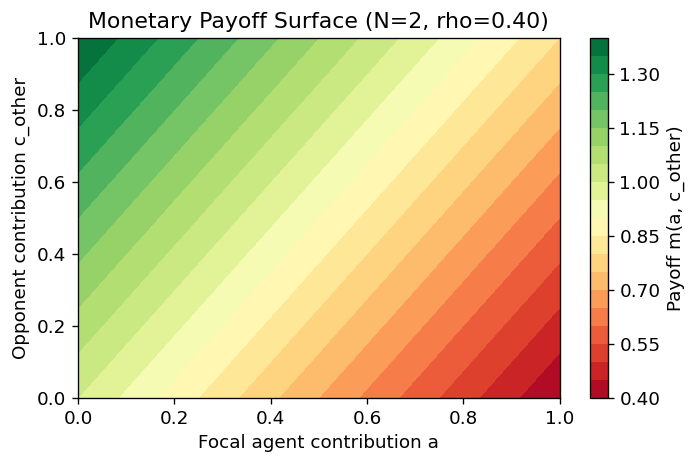

Payoff DECREASES as 'a' increases for fixed opponent → free-riding pays.


In [4]:
def monetary_payoff(a, c_others, rho=rho, e=e):
    return e - a + rho * (a + np.sum(c_others))

# Visualise payoff surface (two-player case)
a_grid = np.linspace(0, 1, 50)
c_grid = np.linspace(0, 1, 50)
A, C   = np.meshgrid(a_grid, c_grid)
M      = e - A + rho * (A + C)

fig, ax = plt.subplots(figsize=(6, 4))
cs = ax.contourf(A, C, M, levels=20, cmap="RdYlGn")
plt.colorbar(cs, ax=ax, label="Payoff m(a, c_other)")
ax.set_xlabel("Focal agent contribution a")
ax.set_ylabel("Opponent contribution c_other")
ax.set_title("Monetary Payoff Surface (N=2, rho=0.40)")
plt.tight_layout(); plt.show()
print("Payoff DECREASES as 'a' increases for fixed opponent → free-riding pays.")


---
## 3 · Subjective Beliefs & Contemporaneous Independence

Because moves are *simultaneous*, the focal agent cannot observe $\mathbf{c}_{-i,t}$ when choosing $a$.
Uncertainty is encoded in a **subjective belief kernel** $G_t(\mathbf{c}_{-i,t}\mid x)\in\Delta(\mathcal{A}^{N-1})$.

**Assumption 1 (Contemporaneous Independence):**
$$G_t(\mathbf{c}_{-i,t}\mid x, a) = G_t(\mathbf{c}_{-i,t}\mid x) \qquad \forall\, t, x, a.$$

No assumption on the distribution is needed; for visualization just here with Beta family.


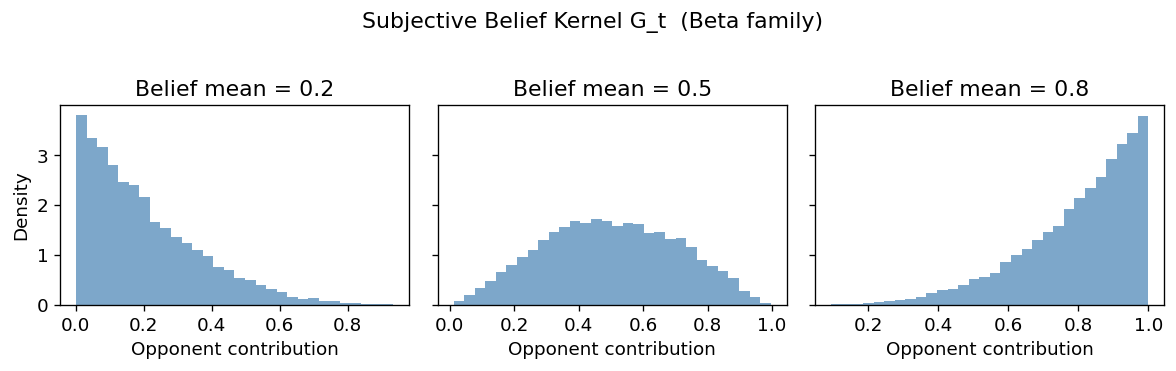

In [5]:
def sample_opponent_contributions(belief_mean, n_opponents=N-1, size=1):
    kappa = 5.0
    alpha = belief_mean * kappa + 1e-6
    beta  = (1 - belief_mean) * kappa + 1e-6
    return rng.beta(alpha, beta, size=(size, n_opponents))

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, mu in zip(axes, [0.2, 0.5, 0.8]):
    samples = sample_opponent_contributions(mu, size=5000).flatten()
    ax.hist(samples, bins=30, color="steelblue", alpha=0.7, density=True)
    ax.set_title(f"Belief mean = {mu}")
    ax.set_xlabel("Opponent contribution")
axes[0].set_ylabel("Density")
fig.suptitle("Subjective Belief Kernel G_t  (Beta family)", y=1.02)
plt.tight_layout(); plt.show()

---
## 4 · Structural Utility with Latent Intentions (Eq. 3)

$$\boxed{u_t(x,a;\,\\\pmb{\theta}_t) = \mathbb{E}_{\mathbf{c}_{-i,t}\sim G_t(\cdot\mid x)}\!\Big[m(a,\mathbf{c}_{-i,t}) + \\\pmb{\theta}_t^\top\\\pmb{\phi}(x,a,\mathbf{c}_{-i,t})\Big]}$$

- $\\\pmb{\theta}_t\in\mathbb{R}^d$ — **latent intention vector** (the quantity we want to *identify*).
- $\\\pmb{\phi}$ — **social feature vector**, e.g. inequity aversion or reciprocity gaps.

The monetary coefficient is normalised to **1** so utility and $\theta_k$ are measured in *token-equivalent* units.

e.g. a $\theta_0 = 1.5$ means the agent values $1$ unit of equity reduction as much as $1.5$ tokens of monetary payoff.  

### Social Features Used in This Simulation

| Feature | Formula | Captures |
|---------|---------|---------|
| Inequity aversion | $-|m_i - \bar{m}_{-i}|$ | Dislike of payoff disparity |
| Reciprocity | $a - \bar{c}_{-i,t-1}$ | Matching past opponent average |


In [6]:
def structural_utility(a, c_samples, theta, prev_avg_opp):
    """
    Expected structural utility averaged over opponent contribution samples.

    Parameters
    ----------
    a            : scalar  — focal agent's action
    c_samples    : (S, N-1) array — sampled opponent contributions
    theta        : (2,) array — [theta_0 (equity aversion), theta_1 (reciprocity)]
    prev_avg_opp : scalar  — previous round's average opponent contribution

    Returns
    -------
    float — E_{G_t}[m(a, c_{-i}) + theta' phi(x, a, c_{-i})]
    """
    # Focal agent monetary payoff for each sampled opponent profile
    m_i = np.array([monetary_payoff(a, c_samples[s]) for s in range(len(c_samples))])

    # Each opponent j's payoff: e - c_j + rho * (total pool)
    total_pool = a + c_samples.sum(axis=1)          # shape (S,)
    m_others   = e - c_samples + rho * total_pool[:, np.newaxis]  # (S, N-1)
    m_avg_others = m_others.mean(axis=1)            # shape (S,)

    # Feature 0 — inequity aversion: disutility of payoff gap
    phi_0 = -np.abs(m_i - m_avg_others)

    # Feature 1 — reciprocity: how much focal agent contributes above past opponent avg
    phi_1 = np.full(len(c_samples), a - prev_avg_opp)

    return np.mean(m_i + theta[0] * phi_0 + theta[1] * phi_1)

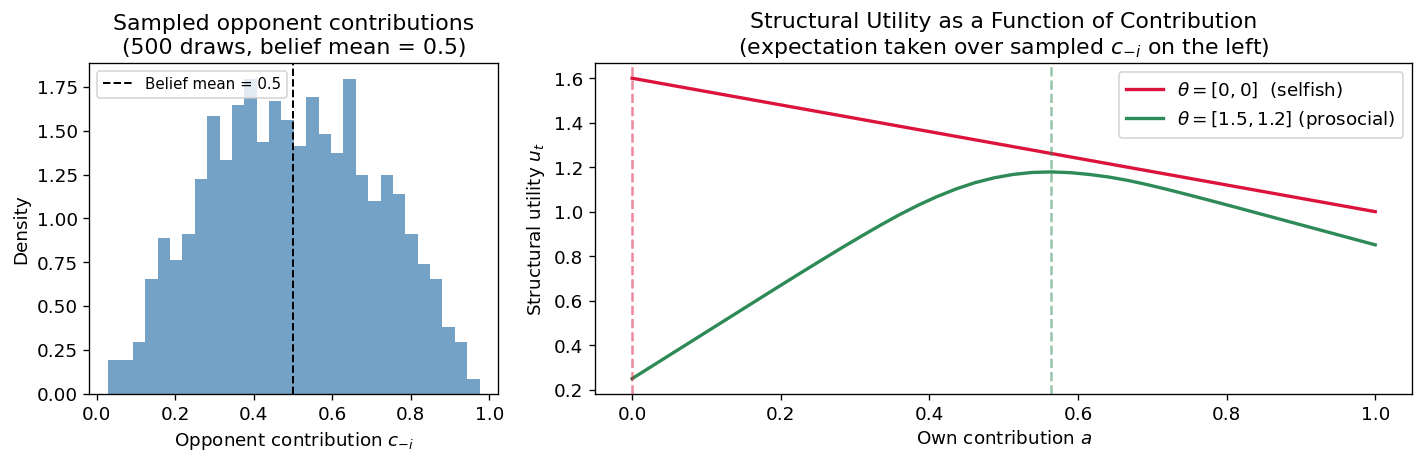

In [7]:
theta_selfish   = np.array([0.0,  0.0])
theta_prosocial = np.array([1.5,  1.2])
a_vals    = np.linspace(0, 1, 40)
c_samples = sample_opponent_contributions(0.5, size=500)   # 500 draws from Beta(belief_mean=0.5)

u_sel = [structural_utility(a, c_samples, theta_selfish,   0.5) for a in a_vals]
u_pro = [structural_utility(a, c_samples, theta_prosocial, 0.5) for a in a_vals]

fig, (ax_dist, ax_u) = plt.subplots(1, 2, figsize=(12, 4),
                                     gridspec_kw={"width_ratios": [1, 2]})

# Left: distribution of sampled opponent contributions
ax_dist.hist(c_samples.flatten(), bins=30, color="steelblue", alpha=0.75, density=True)
ax_dist.axvline(0.5, color="black", ls="--", lw=1.2, label="Belief mean = 0.5")
ax_dist.set_xlabel("Opponent contribution $c_{-i}$")
ax_dist.set_ylabel("Density")
ax_dist.set_title("Sampled opponent contributions\n(500 draws, belief mean = 0.5)")
ax_dist.legend(fontsize=9)

# Right: structural utility curves
ax_u.plot(a_vals, u_sel, label=r"$\theta=[0,0]$  (selfish)",      color="crimson",  lw=2)
ax_u.plot(a_vals, u_pro, label=r"$\theta=[1.5,1.2]$ (prosocial)", color="seagreen", lw=2)
ax_u.axvline(a_vals[np.argmax(u_sel)], ls="--", color="crimson",  alpha=0.5)
ax_u.axvline(a_vals[np.argmax(u_pro)], ls="--", color="seagreen", alpha=0.5)
ax_u.set_xlabel("Own contribution $a$")
ax_u.set_ylabel("Structural utility $u_t$")
ax_u.set_title("Structural Utility as a Function of Contribution\n"
               r"(expectation taken over sampled $c_{-i}$ on the left)")
ax_u.legend()

plt.tight_layout()
plt.show()

---
## 5 · Bounded Rationality: Soft Q-Function, Value & CCP (Eqs. 4–6)

### From Standard Q-Learning to the Soft Version

Recall the standard Q-learning Bellman update:

$$Q_{\text{new}}(s,a) = (1-\alpha)\,Q_{\text{old}}(s,a) + \alpha\!\left[r + \gamma \max_{a'} Q_{\text{old}}(s',a')\right]$$

The learning rate $\alpha \in (0,1]$ controls how fast estimates are updated. This is an **iterative algorithm** — it is run repeatedly until $Q$ stops changing. At convergence ($Q_{\text{new}} = Q_{\text{old}} \equiv Q^*$), the $\alpha$ terms cancel and we are left with the **Bellman fixed-point equation**:

$$\underbrace{(1-\alpha)Q^* + \alpha Q^*}_{= Q^*} = (1-\alpha)Q^* + \alpha\!\left[r + \gamma\max_{a'}Q^*(s',a')\right]$$

$$\implies \boxed{Q^*(s,a) = r + \gamma\max_{a'}Q^*(s',a')}$$

### Why Replace `max` with `log-sum-exp`?

Standard Q-learning also assumes a **perfect optimizer** at the fixed point (hard max). Here we additionally add an **entropy bonus** $\tau\,\mathcal{H}(\pi)$ to the reward, penalising overly deterministic play. The fixed-point equation then becomes the **soft Bellman equation**:

$$\underbrace{V_t(x) = \tau\log\sum_{a'\in\mathcal{A}}\exp\!\left(\frac{Q_t(x,a')}{\tau}\right)}_{\text{soft value (log-sum-exp)}} \qquad \longleftarrow \qquad \underbrace{V_t(x) = \max_{a'}Q_t(x,a')}_{\text{standard hard max}}$$

As $\tau \to 0$ the log-sum-exp converges to the hard max, recovering standard Q-learning at the fixed point.

### Soft Q-Function
$$\boxed{Q_t(x,a;\,\pmb{\theta}_t,\tau_t) = u_t(x,a;\,\pmb{\theta}_t) + \gamma\,\bar{V}_{t+1}(x,a)}$$

### Soft Value Function
$$\boxed{V_t(x) = \tau_t \log\!\sum_{a'\in\mathcal{A}} \exp\!\left(\frac{Q_t(x,a';\,\pmb{\theta}_t,\tau_t)}{\tau_t}\right)}$$

Temperature $\tau_t > 0$ governs bounded rationality: $\tau\to 0$ = perfect argmax, $\tau\to\infty$ = uniform random play.

---
### Intuition for $V_t(x) = \tau \log \sum_{a'} \exp\!\left(\tfrac{Q(x,a')}{\tau}\right)$

Let's unpack what happens step by step as $\tau$ changes. Take a fixed set of Q-values and trace through the formula:


- **Step 1 ($Q/\tau$):** Large $\tau$ → $Q/\tau$ is tiny → all actions look the same. Small $\tau$ → differences are amplified.
- **Step 2 ($\exp$):** $\exp$ of something small $\approx 1 + \text{small}$. $\exp$ of something large amplifies the biggest Q hugely.
- **Step 3 ($\sum$):** With large $\tau$: all $\exp(\cdot) \approx 1$ → sum $\approx$ number of actions $|\mathcal{A}|$. With small $\tau$: dominated by the largest $Q$.
- **Step 4 ($\log$):** $\log|\mathcal{A}|$ (large $\tau$) vs $\log e^{Q_{\max}/\tau} = Q_{\max}/\tau$ (small $\tau$).
- **Step 5 ($\times\tau$):** Multiplying back: $\tau \cdot \log|\mathcal{A}|$ vs $\tau \cdot Q_{\max}/\tau = Q_{\max}$.

So:
$$V \xrightarrow{\tau \to 0} \max_{a'} Q(x,a') \qquad\qquad V \xrightarrow{\tau \to \infty} \underbrace{\bar{Q}}_{\text{average}} + \tau\log|\mathcal{A}|$$

The soft value is always **above** the max Q — it adds an entropy bonus that shrinks to zero as $\tau \to 0$.

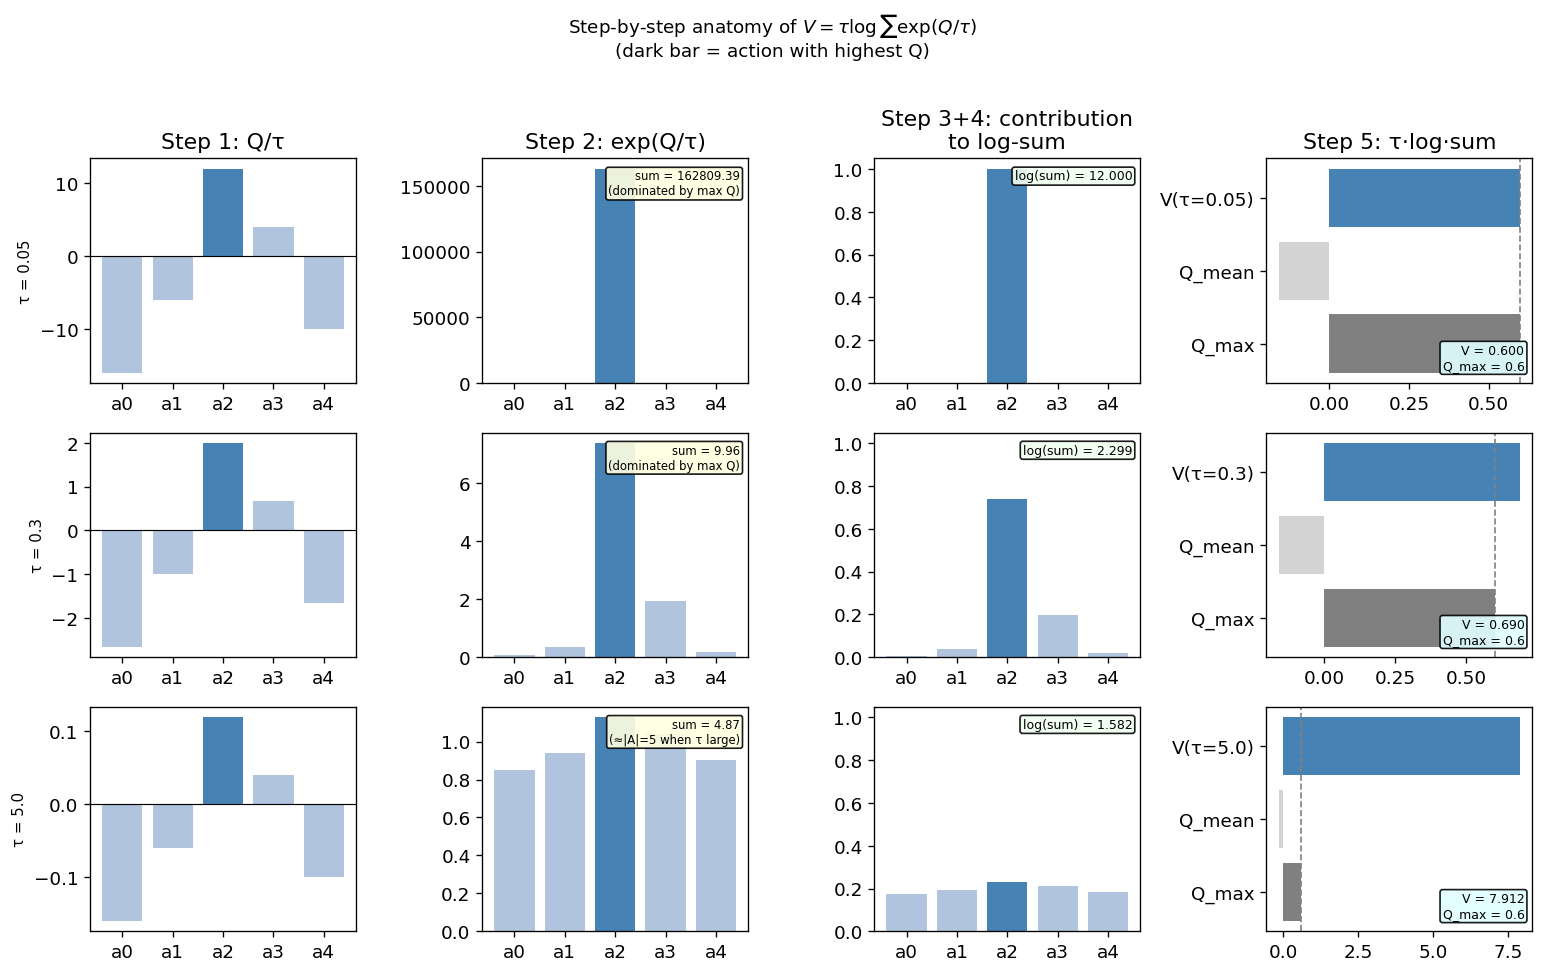

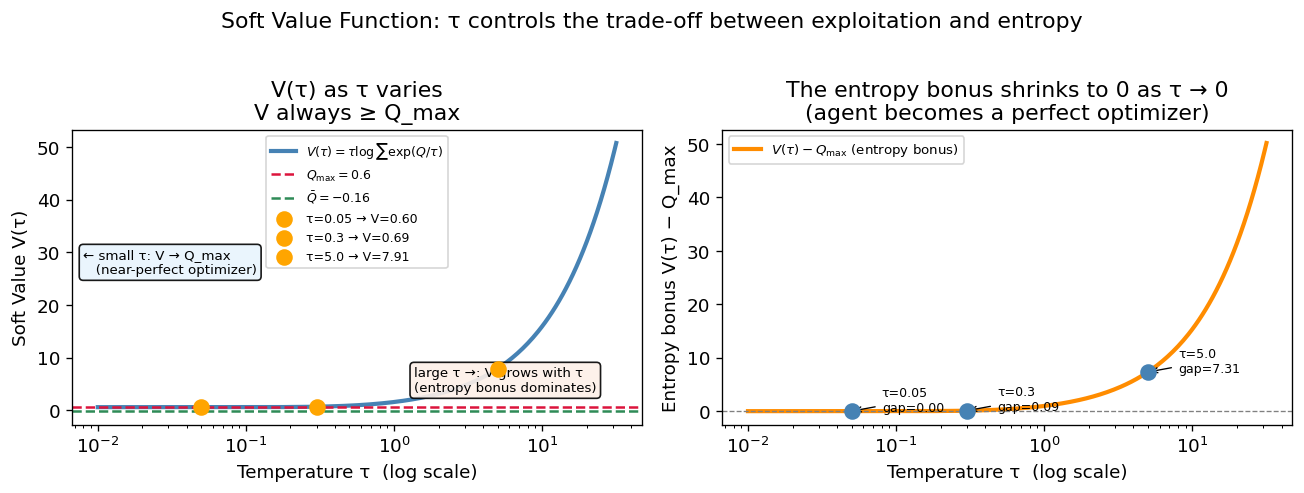

Q values: [-0.8 -0.3  0.6  0.2 -0.5]
Q_max = 0.6,  Q_mean = -0.160

  τ= 0.05:  V = 0.6000  (gap above Q_max = 0.0000)
  τ= 0.30:  V = 0.6897  (gap above Q_max = 0.0897)
  τ= 5.00:  V = 7.9124  (gap above Q_max = 7.3124)


In [8]:
# Fixed Q-values for illustration: 5 actions with a clear best one
Q_example_v = np.array([-0.8, -0.3, 0.6, 0.2, -0.5])   # Q-max at index 2 (= 0.6)
A_labels     = [f"a{i}" for i in range(len(Q_example_v))]
tau_range    = np.logspace(-2, 1.5, 300)   # from 0.01 to ~32

# Compute V(τ) = τ log Σ exp(Q/τ) across the range
V_vals   = [tau * np.log(np.sum(np.exp(Q_example_v / tau))) for tau in tau_range]
Q_max    = np.max(Q_example_v)
Q_mean   = np.mean(Q_example_v)

# ── Figure 1: Step-by-step intermediates for three τ values ──────────────────
tau_examples = [0.05, 0.3, 5.0]
fig, axes = plt.subplots(3, 4, figsize=(13, 8), sharey=False)
step_titles = ["Step 1: Q/τ", "Step 2: exp(Q/τ)", "Step 3+4: contribution\nto log-sum", "Step 5: τ·log·sum"]

for row, tau in enumerate(tau_examples):
    scaled   = Q_example_v / tau
    exped    = np.exp(scaled)
    log_sum  = np.log(np.sum(exped))
    V        = tau * log_sum

    colors = ["steelblue" if q == Q_max else "lightsteelblue" for q in Q_example_v]

    # Step 1
    axes[row, 0].bar(A_labels, scaled, color=colors)
    axes[row, 0].axhline(0, color="k", lw=0.7)
    axes[row, 0].set_title(step_titles[0] if row == 0 else "")
    axes[row, 0].set_ylabel(f"τ = {tau}", fontsize=9)

    # Step 2
    axes[row, 1].bar(A_labels, exped, color=colors)
    axes[row, 1].set_title(step_titles[1] if row == 0 else "")
    note2 = f"sum = {np.sum(exped):.2f}\n(≈|A|={len(Q_example_v)} when τ large)" if tau >= 1 \
            else f"sum = {np.sum(exped):.2f}\n(dominated by max Q)"
    axes[row, 1].text(0.97, 0.95, note2, transform=axes[row,1].transAxes,
                      fontsize=7, va="top", ha="right",
                      bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.9))

    # Step 3+4: each bar = exp(Q_i/τ)/sum = contribution to sum (= CCP weight)
    axes[row, 2].bar(A_labels, exped / np.sum(exped), color=colors)
    axes[row, 2].set_title(step_titles[2] if row == 0 else "")
    axes[row, 2].set_ylim(0, 1.05)
    axes[row, 2].text(0.97, 0.95, f"log(sum) = {log_sum:.3f}",
                      transform=axes[row,2].transAxes, fontsize=7.5, va="top", ha="right",
                      bbox=dict(boxstyle="round,pad=0.2", fc="honeydew", alpha=0.9))

    # Step 5: final V vs Q_max vs Q_mean
    ax = axes[row, 3]
    ax.barh(["Q_max", "Q_mean", f"V(τ={tau})"],
            [Q_max, Q_mean, V],
            color=["gray", "lightgray", "steelblue"])
    ax.axvline(Q_max, color="gray", lw=1, ls="--")
    ax.set_title(step_titles[3] if row == 0 else "")
    ax.text(0.97, 0.05, f"V = {V:.3f}\nQ_max = {Q_max:.1f}",
            transform=ax.transAxes, fontsize=7.5, va="bottom", ha="right",
            bbox=dict(boxstyle="round,pad=0.2", fc="lightcyan", alpha=0.9))

plt.suptitle("Step-by-step anatomy of $V = \\tau \\log \\sum \\exp(Q/\\tau)$\n"
             "(dark bar = action with highest Q)", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

# ── Figure 2: V(τ) vs τ ── the main intuition plot ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.semilogx(tau_range, V_vals,   color="steelblue", lw=2.5, label="$V(\\tau) = \\tau\\log\\sum\\exp(Q/\\tau)$")
ax.axhline(Q_max,  color="crimson",  lw=1.5, ls="--", label=f"$Q_{{\\max}} = {Q_max}$")
ax.axhline(Q_mean, color="seagreen", lw=1.5, ls="--", label=f"$\\bar{{Q}} = {Q_mean:.2f}$")
for tau_ex in tau_examples:
    v = tau_ex * np.log(np.sum(np.exp(Q_example_v / tau_ex)))
    ax.scatter([tau_ex], [v], s=80, zorder=5, color="orange",
               label=f"τ={tau_ex} → V={v:.2f}" if tau_ex == tau_examples[0] else f"τ={tau_ex} → V={v:.2f}")
ax.set_xlabel("Temperature τ  (log scale)")
ax.set_ylabel("Soft Value V(τ)")
ax.set_title("V(τ) as τ varies\nV always ≥ Q_max")
ax.legend(fontsize=7.5)
ax.text(0.02, 0.55,
        "← small τ: V → Q_max\n   (near-perfect optimizer)",
        transform=ax.transAxes, fontsize=8, va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#e8f4fd", alpha=0.9))
ax.text(0.60, 0.15,
        "large τ →: V grows with τ\n(entropy bonus dominates)",
        transform=ax.transAxes, fontsize=8, va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="#fdf0e8", alpha=0.9))

# Panel B: gap = V - Q_max (the entropy bonus)
ax = axes[1]
gap = np.array(V_vals) - Q_max
ax.semilogx(tau_range, gap, color="darkorange", lw=2.5, label="$V(\\tau) - Q_{\\max}$ (entropy bonus)")
ax.axhline(0, color="gray", lw=0.8, ls="--")
for tau_ex in tau_examples:
    v   = tau_ex * np.log(np.sum(np.exp(Q_example_v / tau_ex)))
    ax.scatter([tau_ex], [v - Q_max], s=80, zorder=5, color="steelblue")
    ax.annotate(f"τ={tau_ex}\ngap={v-Q_max:.2f}",
                xy=(tau_ex, v - Q_max), xytext=(tau_ex * 1.6, v - Q_max + 0.05),
                fontsize=7.5, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Temperature τ  (log scale)")
ax.set_ylabel("Entropy bonus V(τ) − Q_max")
ax.set_title("The entropy bonus shrinks to 0 as τ → 0\n(agent becomes a perfect optimizer)")
ax.legend(fontsize=8)

plt.suptitle("Soft Value Function: τ controls the trade-off between exploitation and entropy", y=1.02)
plt.tight_layout()
plt.show()

print(f"Q values: {Q_example_v}")
print(f"Q_max = {Q_max},  Q_mean = {Q_mean:.3f}")
print()
for tau in tau_examples:
    v = tau * np.log(np.sum(np.exp(Q_example_v / tau)))
    print(f"  τ={tau:5.2f}:  V = {v:.4f}  (gap above Q_max = {v - Q_max:.4f})")

### CCP vs. $\varepsilon$-Greedy — Same Goal, Different Logic

Now that we understand how the Q-values are computed, the next question is: **how does the agent choose an action?**

In standard Q-learning, action selection is typically modeled using an **$\varepsilon$-greedy policy**. The agent balances exploration and exploitation:

- with probability $\varepsilon$, it explores (chooses a random action)  
- with probability $1 - \varepsilon$, it exploits (chooses the action with the highest Q-value)

$$
\varepsilon\text{-greedy:} \quad 
a = 
\begin{cases} 
\text{random action}, & \text{with probability } \varepsilon \\ 
\arg\max_a Q(s,a), & \text{with probability } 1 - \varepsilon 
\end{cases}
$$

---

An alternative is the **Conditional Choice Probability (CCP)** or **softmax policy**, where actions are chosen probabilistically based on their Q-values:

$$
\text{CCP (softmax):} \quad 
P_t(a \mid x) = \frac{\exp(Q_t(x,a)/\tau)}{\sum_{a'} \exp(Q_t(x,a')/\tau)}
$$

---

#### Key Difference

- **$\varepsilon$-greedy** introduces randomness *externally*: the agent occasionally ignores Q-values and explores uniformly.  
- **Softmax (CCP)** introduces randomness *internally*: all actions are chosen with probabilities that depend smoothly on their Q-values.

The CCP formulation is a **structural model of behavior**: agents are not perfect optimizers but choose better actions more often, with the degree of randomness governed by $\tau$.

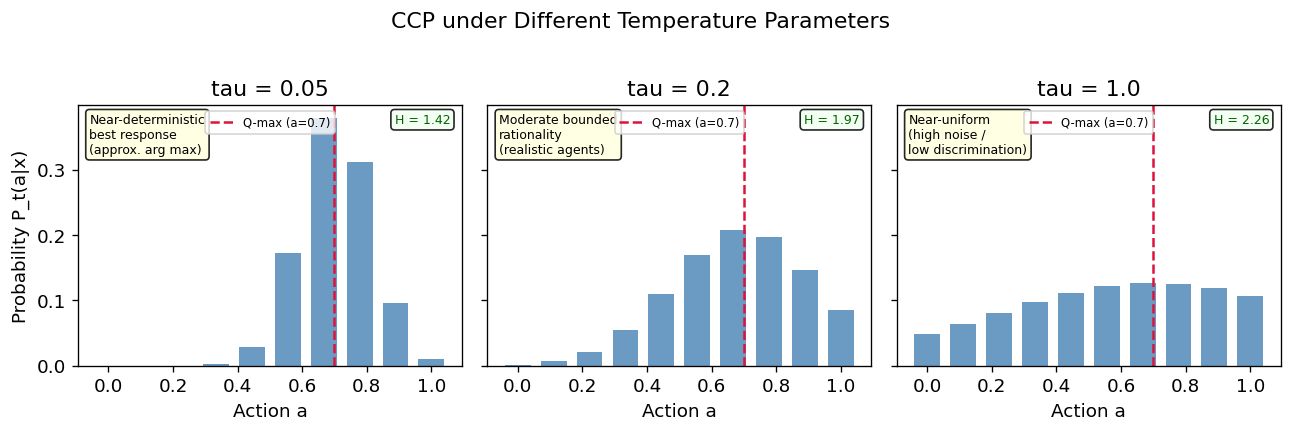

In [9]:
def soft_value(Q_vals, tau):
    return tau * np.log(np.sum(np.exp(Q_vals / tau)))

def ccp(Q_vals, tau):
    return softmax(Q_vals / tau)

# Effect of tau on CCP
a_grid    = np.linspace(0, 1, 10)
Q_example = -2.0 * (a_grid - 0.7)**2   # peaked at a=0.7

# Per-panel behavioral interpretation labels
interp_labels = {
    0.05: "Near-deterministic\nbest response\n(approx. arg max)",
    0.20: "Moderate bounded\nrationality\n(realistic agents)",
    1.0:  "Near-uniform\n(high noise /\nlow discrimination)",
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
for ax, tau in zip(axes, [0.05, 0.20, 1.0]):
    probs   = ccp(Q_example, tau)
    entropy = -np.sum(probs * np.log(probs + 1e-12))  # Shannon entropy
    ax.bar(a_grid, probs, width=0.08, color="steelblue", alpha=0.8)
    # Mark the Q-maximising action
    ax.axvline(0.7, color="crimson", lw=1.5, ls="--", label="Q-max (a=0.7)")
    ax.set_title(f"tau = {tau}")
    ax.set_xlabel("Action a")
    # Behavioral interpretation (top-left)
    ax.text(0.03, 0.97, interp_labels[tau], transform=ax.transAxes,
            fontsize=7.5, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.85))
    # Shannon entropy (top-right) — higher H means more uniform / less informative
    ax.text(0.97, 0.97, f"H = {entropy:.2f}", transform=ax.transAxes,
            fontsize=7.5, va="top", ha="right", color="darkgreen",
            bbox=dict(boxstyle="round,pad=0.3", fc="honeydew", alpha=0.85))
    ax.legend(fontsize=7, loc="upper center")
axes[0].set_ylabel("Probability P_t(a|x)")
fig.suptitle("CCP under Different Temperature Parameters", y=1.02)
plt.tight_layout(); plt.show()

### Figure 1 — CCPs on the action simplex $\Delta(\mathcal{A})$

The paper presents the same $\tau$-effect geometrically. For $\mathcal{A} = \{0, 1, 2\}$, every CCP is a point in the probability simplex
$\Delta(\mathcal{A}) = \{(p_0, p_1, p_2) \in \mathbb{R}^3_{\ge 0} : p_0 + p_1 + p_2 = 1\}$, drawn as an equilateral triangle:

- $\tau \to 0$: mass collapses onto the Q-maximising vertex (full defection if money dominates).
- $\tau \approx 1$: moderate noise spreads mass across neighbouring actions.
- $\tau \to \infty$: the policy converges to the uniform distribution — the centroid $(\tfrac{1}{3}, \tfrac{1}{3}, \tfrac{1}{3})$.

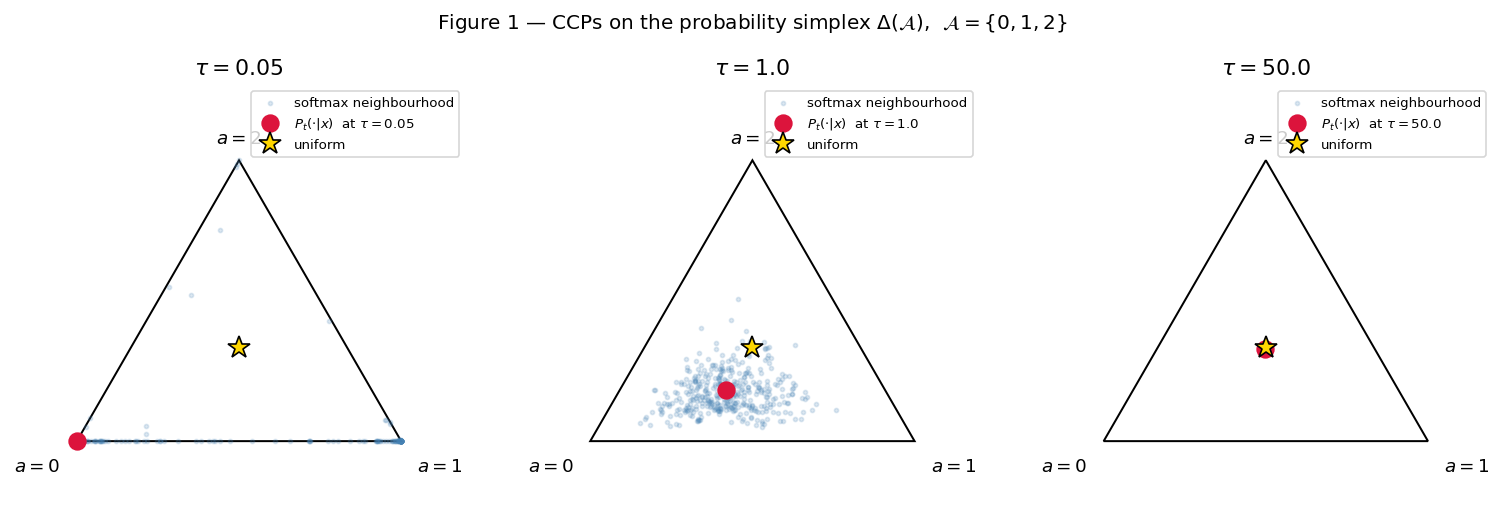

As tau decreases, CCP mass concentrates near the vertex with the largest Q.
As tau increases, CCP moves toward the centroid (uniform distribution).


In [10]:
# Reproduce paper Figure 1 — CCPs on the 3-action simplex Delta(A)
# Vertices of the equilateral triangle for barycentric coordinates
v0 = np.array([0.0, 0.0])           # vertex for a = 0
v1 = np.array([1.0, 0.0])           # vertex for a = 1
v2 = np.array([0.5, np.sqrt(3) / 2])  # vertex for a = 2
verts = np.stack([v0, v1, v2])

def bary_to_xy(p):
    # Map (p0, p1, p2) on the simplex to a 2D point in the triangle
    p = np.asarray(p)
    return p[..., 0:1] * v0 + p[..., 1:2] * v1 + p[..., 2:3] * v2

def softmax_simplex(Q, tau):
    Q = np.asarray(Q)
    s = Q / tau
    s = s - s.max()
    e = np.exp(s)
    return e / e.sum()

# Q-values for actions 0, 1, 2 — defection-dominant case
Q_simplex = np.array([0.6, 0.2, -0.4])

tau_list = [0.05, 1.0, 50.0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, tau in zip(axes, tau_list):
    # Draw triangle
    tri = plt.Polygon(verts, fill=False, edgecolor="black", linewidth=1.2)
    ax.add_patch(tri)
    # Label vertices
    ax.text(v0[0] - 0.05, v0[1] - 0.05, r"$a=0$", fontsize=11, ha="right", va="top")
    ax.text(v1[0] + 0.05, v1[1] - 0.05, r"$a=1$", fontsize=11, ha="left",  va="top")
    ax.text(v2[0],        v2[1] + 0.04, r"$a=2$", fontsize=11, ha="center", va="bottom")

    # Shade slab of CCPs for a range of representative Q perturbations around the same shape
    p_centre = softmax_simplex(Q_simplex, tau)
    # Generate cloud of nearby CCPs by jittering Q (illustrates the softmax neighbourhood)
    rng_local = np.random.default_rng(1)
    cloud = np.array([
        softmax_simplex(Q_simplex + rng_local.normal(scale=0.4, size=3), tau)
        for _ in range(400)
    ])
    cloud_xy = bary_to_xy(cloud)
    ax.scatter(cloud_xy[:, 0], cloud_xy[:, 1], s=6, color="steelblue", alpha=0.18,
               label="softmax neighbourhood")

    # Mark the centre CCP
    p_xy = bary_to_xy(p_centre)
    ax.plot(*p_xy, "o", color="crimson", markersize=10, label=f"$P_t(\\cdot|x)$  at $\\tau={tau}$")

    # Centroid (uniform) for reference
    centroid = bary_to_xy(np.array([1/3, 1/3, 1/3]))
    ax.plot(*centroid, "*", color="gold", markersize=14, markeredgecolor="black", label="uniform")

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"$\\tau = {tau}$")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(r"Figure 1 — CCPs on the probability simplex $\Delta(\mathcal{A})$,  $\mathcal{A}=\{0,1,2\}$",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("As tau decreases, CCP mass concentrates near the vertex with the largest Q.")
print("As tau increases, CCP moves toward the centroid (uniform distribution).")

### Intuition 
Same Q-values, same $\tau$ — now trace the formula step by step:

**Step 1 ($Q/\tau$):** Exactly the same as in the soft value — $\tau$ controls how much Q-differences are amplified.

**Step 2 ($\exp$):** Turns scaled Q-values into positive raw weights. The action with the highest Q gets the biggest weight; everything else gets squashed relative to it.

**Step 3 (÷ sum):** Divides by the total so weights sum to 1 — this is just normalisation.

**The key insight — the denominator is $e^{V/\tau}$:**

Because $V = \tau \log \sum \exp(Q/\tau)$, we have $\sum_{a'} \exp(Q/\tau) = e^{V/\tau}$. So:

$$\boxed{P(a \mid x) = \exp\!\left(\frac{Q(x,a) - V(x)}{\tau}\right)}$$

The CCP depends **only on the advantage** $Q(x,a) - V(x)$: how much better action $a$ is than the average (soft) value. If $Q(x,a) = V(x)$, the action gets probability $e^0 = 1$... divided by $|\mathcal{A}|$ after normalisation.

- Small $\tau$: small advantage differences get hugely amplified → near-deterministic best-response
- Large $\tau$: $Q/\tau \approx 0$ for all actions → $\exp(\cdot) \approx 1$ for all → uniform distribution

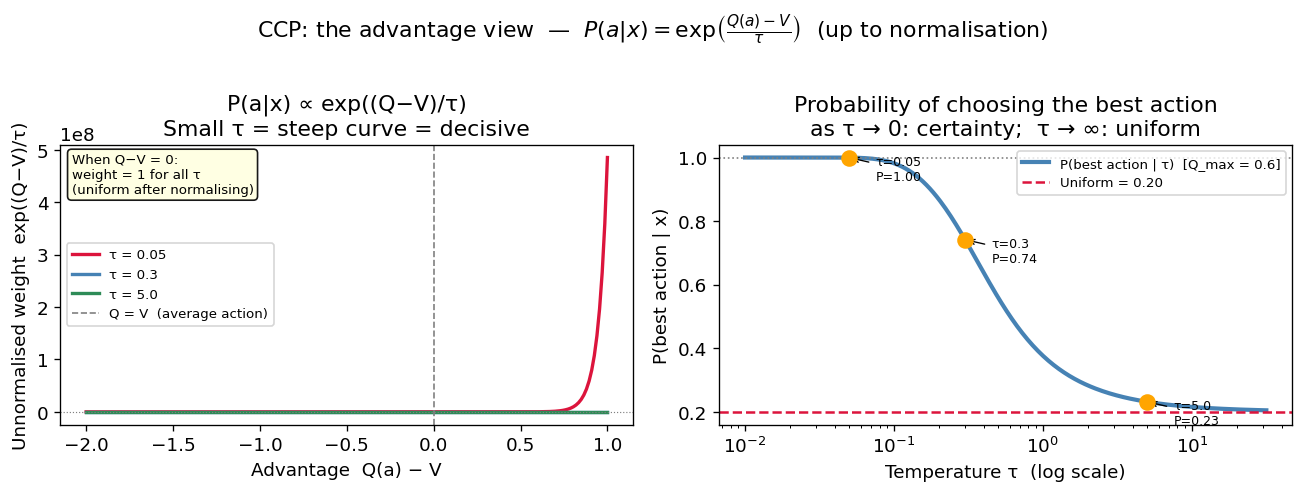

In [11]:
# Same Q-values as the soft-V example so you can compare directly
# Q_example_v and tau_examples are already defined above

# ── Figure 2: advantage view  P(a|x) = exp((Q−V)/τ) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: P vs advantage for the three τ values
adv_range = np.linspace(-2, 1, 200)
ax = axes[0]
for tau, color in zip(tau_examples, ["crimson", "steelblue", "seagreen"]):
    ax.plot(adv_range, np.exp(adv_range / tau), lw=2, color=color, label=f"τ = {tau}")
ax.axvline(0, color="gray", lw=1, ls="--", label="Q = V  (average action)")
ax.axhline(1, color="gray", lw=0.7, ls=":")
ax.set_xlabel("Advantage  Q(a) − V")
ax.set_ylabel("Unnormalised weight  exp((Q−V)/τ)")
ax.set_title("P(a|x) ∝ exp((Q−V)/τ)\nSmall τ = steep curve = decisive")
ax.legend(fontsize=8)
ax.text(0.02, 0.97,
        "When Q−V = 0:\nweight = 1 for all τ\n(uniform after normalising)",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9))

# Panel B: probability of the best action as τ varies
best_prob = [ccp(Q_example_v, tau)[np.argmax(Q_example_v)] for tau in tau_range]
ax = axes[1]
ax.semilogx(tau_range, best_prob, color="steelblue", lw=2.5,
            label=f"P(best action | τ)  [Q_max = {Q_max}]")
ax.axhline(1/len(Q_example_v), color="crimson", lw=1.5, ls="--",
           label=f"Uniform = {1/len(Q_example_v):.2f}")
ax.axhline(1.0, color="gray", lw=1, ls=":")
for tau_ex in tau_examples:
    p = ccp(Q_example_v, tau_ex)[np.argmax(Q_example_v)]
    ax.scatter([tau_ex], [p], s=80, zorder=5, color="orange")
    ax.annotate(f"τ={tau_ex}\nP={p:.2f}", xy=(tau_ex, p),
                xytext=(tau_ex*1.5, p - 0.07), fontsize=7.5,
                arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Temperature τ  (log scale)")
ax.set_ylabel("P(best action | x)")
ax.set_title("Probability of choosing the best action\nas τ → 0: certainty;  τ → ∞: uniform")
ax.legend(fontsize=8)

plt.suptitle("CCP: the advantage view  —  $P(a|x) = \\exp\\!\\left(\\frac{Q(a)-V}{\\tau}\\right)$  (up to normalisation)", y=1.02)
plt.tight_layout()
plt.show()

## 6 · The Belief-Free Monetary Gradient (Lemma 1)

### Statement

$$
\boxed{
\Delta \mathbb{E}_{G_t}[m(a,a')] 
= \mathbb{E}[m(a)] - \mathbb{E}[m(a')] 
= -(1-\rho)(a - a')
}
$$

---

### Derivation

**Step 1 — Payoff function:**

$$m(a, \mathbf{c}_{-i}) = e - a + \rho\!\left(a + \sum_{j \neq i} c_j\right)$$

**Step 2 — Rearrange:**

$$m(a, \mathbf{c}_{-i}) = e - (1-\rho)\,a + \rho\sum_{j \neq i} c_j$$

**Step 3 — Take expectations** (the opponent term becomes a belief-weighted sum $E$):

$$\mathbb{E}_{G_t}[m(a,\mathbf{c}_{-i}) \mid x] = e - (1-\rho)\,a + \rho\,E$$

**Step 4 — Compare two actions** $a$ and $a'$:

$\require{cancel}$

$$
\begin{aligned}
\Delta &= \mathbb{E}[m(a)] - \mathbb{E}[m(a')] \\[6pt]
       &= \Bigl(\cancel{e} - (1-\rho)\,a + \cancel{\rho E}\Bigr) 
          - \Bigl(\cancel{e} - (1-\rho)\,a' + \cancel{\rho E}\Bigr) \\[6pt]
       &\phantom{{}={}}
        \underbrace{\hspace{7cm}}_{\cancel{e},\;\cancel{\rho E}\text{ appear in both terms and vanish}} \\[-8pt]
       &= -(1-\rho)\,a + (1-\rho)\,a' \\[6pt]
       &= \boxed{-(1-\rho)(a-a')}
\end{aligned}
$$

> **Key insight:** $e$ and $\rho E$ are identical in both terms and cancel exactly.  
> The opponent's contribution is irrelevant to *which action to choose* — only the institutional parameter $(1-\rho)$ remains.

---

Economic Interpretation: The marginal cost of contributing is $-(1-\rho)$ — a **fixed institutional parameter**, independent of beliefs, history, or opponent behavior. Beliefs shift payoff *levels* but not *marginal incentives*, making the gradient **belief-free** and providing a clean **identification anchor**.

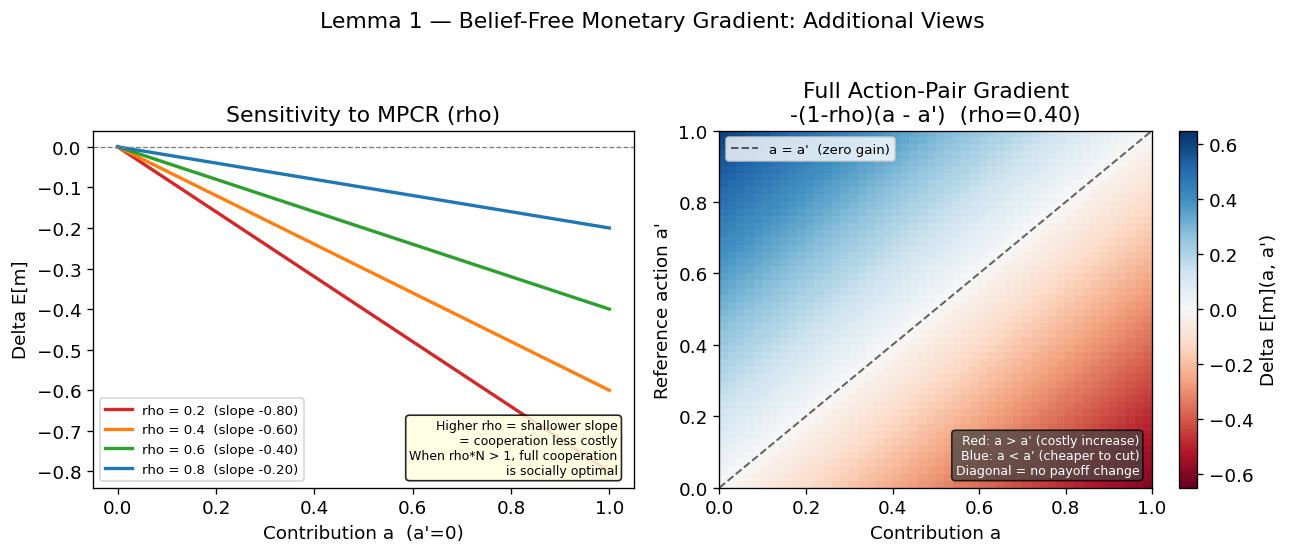

In [12]:
def belief_free_gradient(a, a_prime, rho=rho):
    return -(1 - rho) * (a - a_prime)

a_vals = np.linspace(0, 1, 50)

# --- Figure 2: two additional panels ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A: sensitivity to rho — slope = -(1-rho), so higher rho = shallower = cheaper cooperation
ax = axes[0]
rho_grid   = [0.20, 0.40, 0.60, 0.80]
rho_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
for rv, c in zip(rho_grid, rho_colors):
    ax.plot(a_vals, [-(1 - rv) * a for a in a_vals],
            lw=2, color=c, label=f"rho = {rv}  (slope {-(1-rv):.2f})")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Contribution a  (a'=0)")
ax.set_ylabel("Delta E[m]")
ax.set_title("Sensitivity to MPCR (rho)")
ax.legend(fontsize=8)
ax.text(0.97, 0.03,
        "Higher rho = shallower slope\n= cooperation less costly\n"
        "When rho*N > 1, full cooperation\nis socially optimal",
        transform=ax.transAxes, fontsize=7.5, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.85))

# Panel B: 2D heatmap of Delta E[m](a, a') — the full action-pair gradient surface
ax = axes[1]
A_g, Ap_g = np.meshgrid(a_vals, a_vals)
Delta      = -(1 - rho) * (A_g - Ap_g)
im = ax.imshow(Delta, origin="lower", extent=[0, 1, 0, 1],
               cmap="RdBu", vmin=-0.65, vmax=0.65, aspect="auto")
plt.colorbar(im, ax=ax, label="Delta E[m](a, a')")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="a = a'  (zero gain)")
ax.set_xlabel("Contribution a")
ax.set_ylabel("Reference action a'")
ax.set_title("Full Action-Pair Gradient\n-(1-rho)(a - a')  (rho=0.40)")
ax.legend(fontsize=8, loc="upper left")
ax.text(0.97, 0.03,
        "Red: a > a' (costly increase)\nBlue: a < a' (cheaper to cut)\n"
        "Diagonal = no payoff change",
        transform=ax.transAxes, fontsize=7.5, va="bottom", ha="right", color="white",
        bbox=dict(boxstyle="round,pad=0.3", fc="#444", alpha=0.75))

fig.suptitle("Lemma 1 — Belief-Free Monetary Gradient: Additional Views", y=1.02)
plt.tight_layout(); plt.show()


#### Left plot — Sensitivity to $\rho$

If I contribute $a$ instead of $a'=0$, my monetary payoff changes by $\Delta = -(1-\rho)\,a$.
$\Delta$ is always negative — contributing always costs you relative to free-riding.
Higher $\rho$ flattens the slope $(1-\rho)$, meaning cooperation becomes less painful — but 
free-riding remains monetarily dominant regardless. The slope $-(1-\rho)$ is a clean, observable 
measure of the cost of cooperation, fixed by the institution alone.

#### Right plot — Full action-pair gradient

$a'$ is the counterfactual: *"what would my payoff have been had I chosen $a'$ instead of $a$?"*

$$\Delta = -(1-\rho)(a - a')$$

- **Diagonal** $a = a'$: white, $\Delta = 0$ — no difference between actions
- **Below diagonal** $a > a'$: red, $\Delta < 0$ — contributing more than the counterfactual costs you
- **Above diagonal** $a < a'$: blue, $\Delta > 0$ — contributing less than the counterfactual saves you

The gradient depends only on the distance from the diagonal, not on where along it you are. 
Contributing from $0.2$ to $0.5$ costs exactly the same as from $0.5$ to $0.8$ — 
the surface is a flat plane scaled by $(1-\rho)$ alone.

---
## 7 · Exact Algebraic Identification — Setup

The core identification challenge lies in the Logit formulation of the CCP, where the structural parameters $(\boldsymbol{\theta}_t, \tau_t)$ are inherently coupled through the ratio $Q_t / \tau_t$. We now state the conditions under which they are injectively identified at the population level. Two further assumptions on top of Assumption 1 (Contemporaneous Independence) are required.

### Assumption 2 (Well-Defined Population System)

For each period $t \in \{1, \dots, T\}$, the true Data Generating Process satisfies:

1. **Support.** The population CCPs satisfy $P_t(a \mid x) > 0$ over the relevant state-action support $\mathcal{R}_t$.
2. **Beliefs.** The population subjective belief kernel $G_t(\cdot \mid x)$ is strictly known.
3. **Finiteness.** The expected social feature differences $\Delta\boldsymbol{\varphi}_t$ and the continuation-adjusted anchors $\mathbf{c}_t$ are finite, exact population objects on $\mathcal{R}_t$.

### Assumption 3 (Feature Non-Collinearity)

The expected social feature differences $\Delta\boldsymbol{\varphi}_t(r)$ must not be perfectly collinear with the objective monetary anchor. Specifically, latent social features cannot be purely affine functions of the focal agent's own action $a$ independent of the state $x$ or opponents' actions.

If a feature represents pure unconditional altruism or *warm glow* parameterised as $\phi^{(w)}(a) = w \cdot a$, its expected difference is exactly
$$\Delta\varphi^{(w)}(r) = w\,(a - a').$$

Because the Belief-Free Monetary Gradient is strictly $-(1-\rho)(a - a')$, such a feature perfectly spans the monetary anchor ($\mathbf{b}_t \in \operatorname{Col}(\Delta\boldsymbol{\Phi}_t)$), mathematically destroying identification. **Valid social features must incorporate non-linearities in $a$ (e.g. absolute inequity aversion) or interact directly with the state (e.g. reciprocity $a \cdot \bar{c}_{-i,\,t-1}$).**

---
## 8 · The Stacked Structural Equation

To estimate $(\tau_t, \boldsymbol{\theta}_t)$, we exploit the log-odds of the CCPs.

### Valid Comparisons

Fix a period $t$. Define the strict support of valid state-action comparisons from the population CCPs:

$$\mathcal{R}_t = \{r = (x, a, a') : x \in \operatorname{supp}(\mathcal{X}_t),\; a \neq a'\}.$$

For each row $r = (x, a, a') \in \mathcal{R}_t$ under Assumption 2, we define four exact population objects. A row $r = (x, a, a')$ is a **comparison**: at state $x$, how does the agent's choice of $a$ compare to choosing $a'$ instead?

| Object | Formula | Notes |
|--------|---------|-------|
| **Log-odds** $y_t(r)$ | $\log P_t(a\mid x) - \log P_t(a'\mid x)$ | Observable from data |
| **Feature difference** $\Delta\boldsymbol{\varphi}_t(r)$ | $\boldsymbol{\varphi}_t(x,a) - \boldsymbol{\varphi}_t(x,a')$ | Expected social features |
| **Monetary anchor** $b_t(r)$ | $-(1-\rho)(a-a')$ | Belief-free (Lemma 1) |
| **Continuation diff** $d_t(r)$ | $\bar{V}_{t+1}(x,a) - \bar{V}_{t+1}(x,a')$ | $= 0$ exactly at $t=T$ (game over) |

Stack these row-wise across $\mathcal{R}_t$ to form the population log-odds vector $\mathbf{y}_t \in \mathbb{R}^{M_t}$, deterministic constant vectors $\mathbf{b}_t, \mathbf{d}_t \in \mathbb{R}^{M_t}$, and the social feature difference matrix $\Delta\boldsymbol{\Phi}_t \in \mathbb{R}^{M_t \times d}$ whose rows are $\Delta\boldsymbol{\varphi}_t(r)^\top$.

### Definition 1 (Continuation-Adjusted Anchor)

The vector $\mathbf{c}_t \in \mathbb{R}^{M_t}$ is the aggregate deterministic offset at time $t$:

$$\boxed{\;\mathbf{c}_t \;:=\; \mathbf{b}_t \;+\; \gamma\,\mathbf{d}_t.\;}$$

At the terminal period $t = T$, $\mathbf{d}_T = \mathbf{0}$ and so $\mathbf{c}_T = \mathbf{b}_T$ — the pure belief-free monetary gradient.

### The Key Linear System

Taking the log-odds of the CCP (Eq. 6) and substituting the components derived above, the parameter-to-policy map reduces exactly to the fundamental **stacked structural equation** for period $t$:

$$\boxed{\;\tau_t\,\mathbf{y}_t \;=\; \underbrace{\mathbf{c}_t}_{\text{known}} \;+\; \underbrace{\Delta\boldsymbol{\Phi}_t\,\boldsymbol{\theta}_t}_{\text{unknown}}\;}$$

Rearranging, this is a **linear system** in the unknown vector $[\tau_t,\; \boldsymbol{\theta}_t^\top]^\top$:

$$[\,\mathbf{y}_t \;\big|\; -\Delta\boldsymbol{\Phi}_t\,]\;\begin{bmatrix}\tau_t \\ \boldsymbol{\theta}_t\end{bmatrix} = \mathbf{c}_t.$$

This is solvable by OLS *in the population* when $M_t \geq 1+d$ rows are available and the identification conditions (Theorem 1/2) hold. On finite samples, the empirical log-odds $\hat{y}_t$ enter as a noisy regressor and classical errors-in-variables attenuates $\hat\tau$. The project's empirical workhorse is therefore a direct soft-Logit MLE on individual observations (see `bfse_mle.py` and `bfse_static.ipynb`) — but the population OLS view is the foundation of the identification arguments below.

True  τ=0.3,  θ=1.5
Est.  τ=0.3000,  θ=1.5000
60 rows, 2 unknowns, rank=2

Why only 3 distinct constraint lines in Panel B?
  b(r)/Δφ(r) = (1−ρ)/x  — constant for all pairs (a,a') at the same x.
  So all rows at the same x are the SAME line. One line per state.


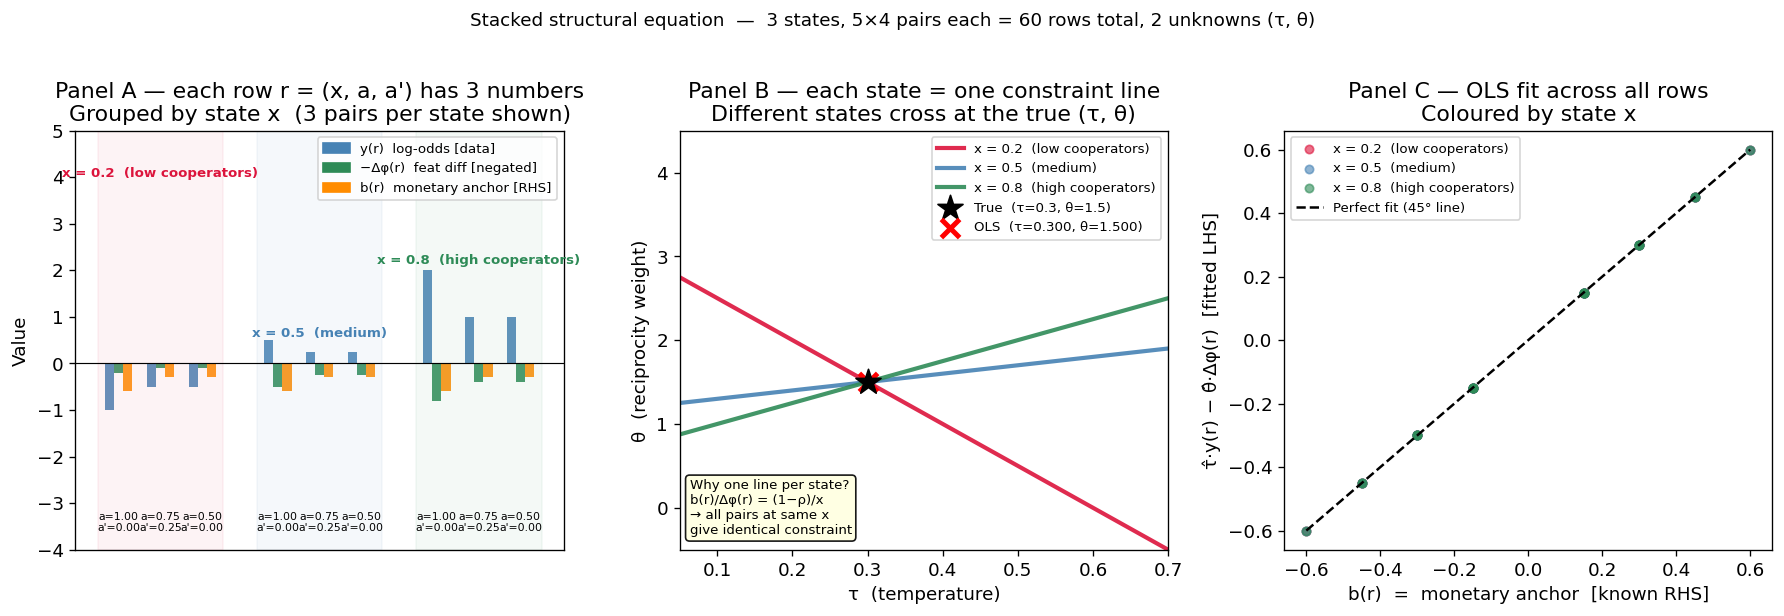

In [13]:
from scipy.linalg import lstsq

# ── Setup ─────────────────────────────────────────────────────────────────────
tau_true   = 0.3
theta_true = 1.5
A_discrete = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
states_all = np.array([0.2, 0.5, 0.8])
rho_val    = 0.4

def make_rows(states):
    rows, b_list, dphi_list, y_list = [], [], [], []
    for x in states:
        Q = np.array([-(1-rho_val)*a + rho_val*x + theta_true*(a*x)
                      for a in A_discrete]) / tau_true
        P = softmax(Q)
        for a in A_discrete:
            for ap in A_discrete:
                if a == ap: continue
                ia  = np.where(A_discrete==a)[0][0]
                iap = np.where(A_discrete==ap)[0][0]
                rows.append((x, a, ap))
                b_list.append(-(1-rho_val)*(a-ap))
                dphi_list.append((a-ap)*x)
                y_list.append(np.log(P[ia]+1e-15) - np.log(P[iap]+1e-15))
    return rows, np.array(b_list), np.array(dphi_list), np.array(y_list)

rows, b_vec, dphi, y_vec = make_rows(states_all)
design = np.column_stack([y_vec, -dphi])
params_hat, *_ = lstsq(design, b_vec)
tau_hat, theta_hat = params_hat[0], params_hat[1]

print(f"True  τ={tau_true},  θ={theta_true}")
print(f"Est.  τ={tau_hat:.4f},  θ={theta_hat:.4f}")
print(f"{len(rows)} rows, 2 unknowns, rank={np.linalg.matrix_rank(design)}")
print()
print("Why only 3 distinct constraint lines in Panel B?")
print("  b(r)/Δφ(r) = (1−ρ)/x  — constant for all pairs (a,a') at the same x.")
print("  So all rows at the same x are the SAME line. One line per state.")

# ── Pick 3 representative pairs per state ─────────────────────────────────────
rep_pairs = [(1.0, 0.0), (0.75, 0.25), (0.5, 0.0)]   # same 3 pairs for each state
state_colors = {0.2: "crimson", 0.5: "steelblue", 0.8: "seagreen"}
state_label  = {0.2: "x = 0.2  (low cooperators)", 0.5: "x = 0.5  (medium)", 0.8: "x = 0.8  (high cooperators)"}

subset_rows = [(x, a, ap) for x in states_all for (a, ap) in rep_pairs]
s_idx   = [rows.index(r) for r in subset_rows]
s_col   = [state_colors[r[0]] for r in subset_rows]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel A: 3 groups (one per state), 3 pairs each ──────────────────────────
ax = axes[0]
group_size = len(rep_pairs)
n_groups   = len(states_all)
gap        = 0.8   # extra space between state groups
w          = 0.22

for g, x in enumerate(states_all):
    base = g * (group_size + gap)
    for p, (a, ap) in enumerate(rep_pairs):
        r   = (x, a, ap)
        idx = rows.index(r)
        pos = base + p
        ax.bar(pos - w, y_vec[idx],   width=w, color="steelblue",  alpha=0.85)
        ax.bar(pos,    -dphi[idx],     width=w, color="seagreen",   alpha=0.85)
        ax.bar(pos + w, b_vec[idx],    width=w, color="darkorange", alpha=0.85)
        ax.text(pos, -3.6, f"a={a:.2f}\na'={ap:.2f}", ha="center", fontsize=6.5)
    # State label as group header
    mid = base + (group_size - 1) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 4,
            state_label[x], ha="center", fontsize=8, color=state_colors[x], fontweight="bold")
    ax.axvspan(base - 0.5, base + group_size - 0.5, alpha=0.05, color=state_colors[x])

ax.axhline(0, color="k", lw=0.7)
ax.set_xticks([]); ax.set_ylabel("Value")
# Manual legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue",  label="y(r)  log-odds [data]"),
                   Patch(color="seagreen",   label="−Δφ(r)  feat diff [negated]"),
                   Patch(color="darkorange", label="b(r)  monetary anchor [RHS]")],
          fontsize=8, loc="upper right")
ax.set_title("Panel A — each row r = (x, a, a') has 3 numbers\n"
             "Grouped by state x  (3 pairs per state shown)")
ax.set_ylim(-4, 5)

# ── Panel B: constraint lines in (τ, θ) space ─────────────────────────────────
ax = axes[1]
tau_grid = np.linspace(0.05, 0.7, 300)
plotted  = set()
for x in states_all:
    # All rows at same x give the SAME line — just plot one per state
    r    = (x, 1.0, 0.0)
    idx  = rows.index(r)
    yr, bval, dfval = y_vec[idx], b_vec[idx], float(-dphi[idx])
    theta_line = (bval - yr * tau_grid) / dfval
    mask = (-0.5 < theta_line) & (theta_line < 4.5)
    ax.plot(tau_grid[mask], theta_line[mask], lw=2.5,
            color=state_colors[x], label=state_label[x], alpha=0.9)

ax.scatter([tau_true], [theta_true], s=250, color="black", zorder=7,
           marker="*", label=f"True  (τ={tau_true}, θ={theta_true})")
ax.scatter([tau_hat],  [theta_hat],  s=120, color="red",   zorder=6,
           marker="x", lw=3, label=f"OLS  (τ={tau_hat:.3f}, θ={theta_hat:.3f})")
ax.set_xlabel("τ  (temperature)"); ax.set_ylabel("θ  (reciprocity weight)")
ax.set_xlim(0.05, 0.7); ax.set_ylim(-0.5, 4.5)
ax.set_title("Panel B — each state = one constraint line\n"
             "Different states cross at the true (τ, θ)")
ax.legend(fontsize=8, loc="upper right")
ax.text(0.02, 0.03,
        "Why one line per state?\nb(r)/Δφ(r) = (1−ρ)/x\n→ all pairs at same x\ngive identical constraint",
        transform=ax.transAxes, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9))

# ── Panel C: OLS fit, coloured by state ──────────────────────────────────────
ax = axes[2]
fitted = design @ params_hat
for x in states_all:
    idx_x = [i for i, r in enumerate(rows) if r[0] == x]
    ax.scatter(b_vec[idx_x], fitted[idx_x], s=25, alpha=0.6,
               color=state_colors[x], label=state_label[x])

ax.plot([b_vec.min(), b_vec.max()], [b_vec.min(), b_vec.max()],
        "k--", lw=1.5, label="Perfect fit (45° line)")
ax.set_xlabel("b(r)  =  monetary anchor  [known RHS]")
ax.set_ylabel("τ̂·y(r) − θ̂·Δφ(r)  [fitted LHS]")
ax.set_title("Panel C — OLS fit across all rows\nColoured by state x")
ax.legend(fontsize=8)

plt.suptitle(f"Stacked structural equation  —  {len(states_all)} states, "
             f"{len(A_discrete)}×{len(A_discrete)-1} pairs each = {len(rows)} rows total, 2 unknowns (τ, θ)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

---
## 9 · Exact Identification — Theorem 1 (Terminal Period)

At the final round $T$: continuation values vanish ($V_{T+1} = 0$), so $\mathbf{d}_T = \mathbf{0}$ and the adjusted anchor reduces to $\mathbf{c}_T = \mathbf{b}_T$ (the pure belief-free monetary gradient).

### Theorem 1
The mapping $(\tau_T, \boldsymbol{\theta}_T) \mapsto \mathbf{y}_T$ is **injective** (point-identified) if and only if:

1. $\operatorname{rank}(\Delta\mathbf{\Phi}_T) = d$ — the social feature matrix has **full column rank** (no redundant features)
2. $\mathbf{b}_T \notin \operatorname{Col}(\Delta\mathbf{\Phi}_T)$ — the monetary anchor is **not spanned** by the social feature differences

### Why the Non-Spanning Condition?

If $\mathbf{b}_T = \Delta\mathbf{\Phi}_T\,\mathbf{v}$ for some $\mathbf{v}$, then for any $\lambda > 0$ the alternative parameters:
$$\tau' = \lambda\tau, \qquad \boldsymbol{\theta}' = \lambda\boldsymbol{\theta} + (\lambda - 1)\mathbf{v}$$
produce the **identical** $\mathbf{y}_T$. Temperature and preferences are hopelessly confounded — the model is unidentified.

### What Destroys Identification: Warm Glow

If $\phi^{(w)}(a) = w \cdot a$ (warm glow / unconditional altruism), its expected difference is:
$$\Delta\varphi^{(w)}(r) = w\,(a - a')$$
which is **exactly proportional** to $b_T(r) = -(1-\rho)(a-a')$.
Warm glow spans the monetary anchor $\Rightarrow$ identification fails.

### Valid Features Must Be State-Dependent or Nonlinear in $a$

| Feature | $\Delta\varphi(r)$ | Spans $b_T$? | Valid? |
|---------|-------------------|-------------|--------|
| Warm glow: $\phi = a$ | $a - a'$ | **Yes** — proportional to $b_T$ | **No** |
| Reciprocity: $\phi = a \cdot x$ | $(a - a') \cdot x$ | No — varies across states | **Yes** |
| Ineq. aversion: $\phi = -\|a - x\|^2$ | $-\|a-x\|^2 + \|a'-x\|^2$ | No — nonlinear in $a$ | **Yes** |

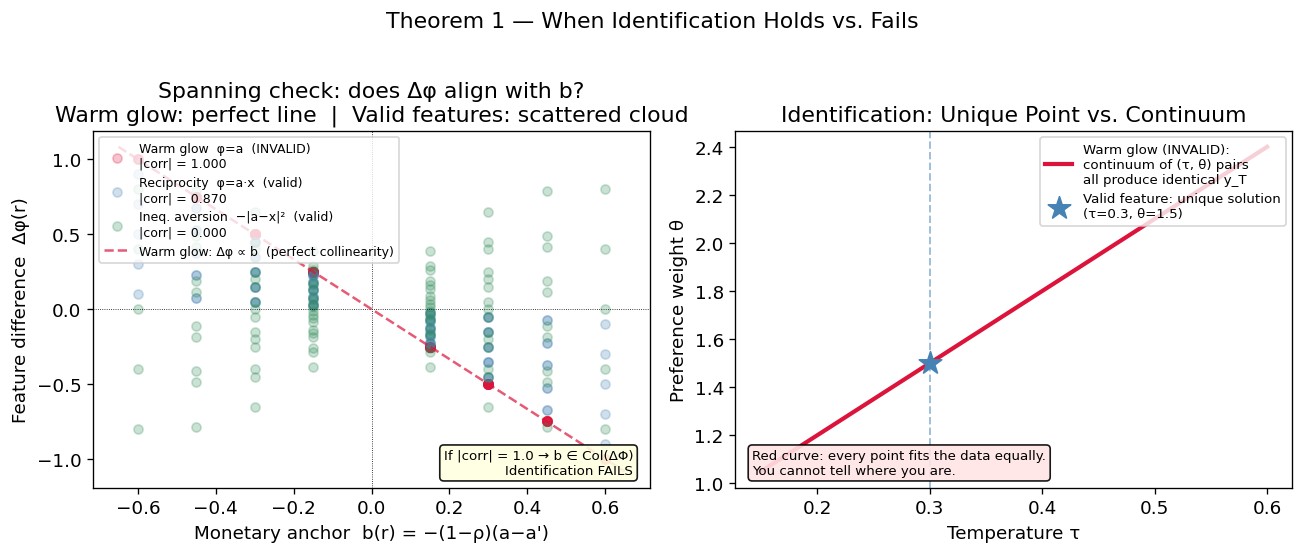

In [14]:
# Visualise identification: spanning check & continuum of solutions
rho_vis  = 0.4   # local copy so this cell is self-contained

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Panel A: spanning check ---
ax = axes[0]
states_vis = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
# Pairs in BOTH directions so b spans the full range −0.6 … +0.6
A_vis  = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
a_pairs_vis = [(a, ap) for a in A_vis for ap in A_vis if a != ap]

features = [
    ("Warm glow  φ=a  (INVALID)",        lambda a, ap, x: a - ap,                   "crimson"),
    ("Reciprocity  φ=a·x  (valid)",       lambda a, ap, x: (a - ap) * x,             "steelblue"),
    ("Ineq. aversion  −|a−x|²  (valid)",  lambda a, ap, x: -(a-x)**2 + (ap-x)**2,  "seagreen"),
]

for label, feat_fn, color in features:
    b_rows    = [-(1 - rho_vis) * (a - ap) for x in states_vis for (a, ap) in a_pairs_vis]
    dphi_rows = [feat_fn(a, ap, x)          for x in states_vis for (a, ap) in a_pairs_vis]
    corr = np.corrcoef(b_rows, dphi_rows)[0, 1]
    ax.scatter(b_rows, dphi_rows,
               label=f"{label}\n|corr| = {abs(corr):.3f}",
               alpha=0.25, s=30, color=color)

# Reference line through origin (slope = 1/(1−ρ) for warm glow)
b_line = np.array([-0.65, 0.65])
ax.plot(b_line, b_line / (1 - rho_vis) * (-1), color="crimson", lw=1.5, ls="--",
        alpha=0.7, label="Warm glow: Δφ ∝ b  (perfect collinearity)")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.axvline(0, color="k", lw=0.5, ls=":")

ax.set_xlabel("Monetary anchor  b(r) = −(1−ρ)(a−a')")
ax.set_ylabel("Feature difference  Δφ(r)")
ax.set_title("Spanning check: does Δφ align with b?\n"
             "Warm glow: perfect line  |  Valid features: scattered cloud")
ax.legend(fontsize=7.5, loc="upper left")
ax.text(0.97, 0.03,
        "If |corr| = 1.0 → b ∈ Col(ΔΦ)\nIdentification FAILS",
        transform=ax.transAxes, fontsize=8, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9))

# --- Panel B: continuum of solutions ---
ax = axes[1]
lambdas        = np.linspace(0.5, 2.0, 200)
tau_true_th1   = 0.3
theta_true_th1 = 1.5
v_wg           = -(1 - rho_vis)   # b = ΔΦ·v  →  v = −(1−ρ)

tau_continuum   = lambdas * tau_true_th1
theta_continuum = lambdas * theta_true_th1 + (lambdas - 1) * v_wg

ax.plot(tau_continuum, theta_continuum, color="crimson", lw=2.5,
        label="Warm glow (INVALID):\ncontinuum of (τ, θ) pairs\nall produce identical y_T")
ax.scatter([tau_true_th1], [theta_true_th1], s=200, color="steelblue", zorder=6,
           marker="*", label=f"Valid feature: unique solution\n(τ={tau_true_th1}, θ={theta_true_th1})")
ax.axvline(tau_true_th1, color="steelblue", lw=1.2, ls="--", alpha=0.5)

ax.set_xlabel("Temperature τ")
ax.set_ylabel("Preference weight θ")
ax.set_title("Identification: Unique Point vs. Continuum")
ax.legend(fontsize=8, loc="upper right")
ax.text(0.03, 0.03,
        "Red curve: every point fits the data equally.\nYou cannot tell where you are.",
        transform=ax.transAxes, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", fc="#ffe5e5", alpha=0.9))

fig.suptitle("Theorem 1 — When Identification Holds vs. Fails", y=1.02)
plt.tight_layout()
plt.show()

### Reading the plots

**Left panel — spanning check**

Each dot is one comparison row $r = (x, a, a')$. The x-axis is $b(r) = -(1-\rho)(a-a')$, the y-axis is the feature difference $\Delta\varphi(r)$ for each feature type. Dots cluster at discrete values because the action grid is discrete — only a fixed set of $(a-a')$ differences exists, so only a fixed set of $b(r)$ values is possible. The gaps you see (e.g. around 0.35–0.45) are just missing action-pair combinations, not a threshold for identification.

What matters is the **shape of the cloud**:
- **Warm glow (red):** all dots lie exactly on a straight line through the origin — |corr| = 1.0. $\Delta\varphi(r) \propto b(r)$ for every row. Identification **fails**.
- **Reciprocity / inequity aversion (blue/green):** dots scatter off that line because they also depend on the state $x$ or are nonlinear in $a$. Identification **holds**.

Identification fails for warm glow (|corr| = 1.0 exactly), not at specific $b$ values like 0.3 or 0.6 — those are just where the discrete action pairs happen to land.

---

**Right panel — the continuum of solutions**

When warm glow is included, for any $\lambda > 0$ the alternative parameter pair
$$\tau' = \lambda\tau, \qquad \theta' = \lambda\theta + (\lambda-1)v$$
produces **identical choice probabilities** to $(\tau, \theta)$. The red curve traces all such pairs — every point on it fits the data equally well. You cannot know where you are on that curve.

**What this does and does not mean economically:**

The red curve slopes upward: as $\tau$ increases (agent becomes more confused/irrational), $\theta$ also increases (agent appears to have stronger preferences). But this is **not** an economic law — it is a statement that **the data is silent**. It cannot tell apart:

- A **rational** agent ($\tau$ small) with **modest** warm-glow preferences ($\theta$ small), or
- A **confused** agent ($\tau$ large) with **strong** warm-glow preferences ($\theta$ large).

Both generate identical contribution patterns. Without the monetary anchor pinning down $\tau$, you can always rewrite one story as the other by rescaling $\lambda$. The preference weight $\theta$ is not interpretable in isolation — it floats freely with $\tau$.

With a **valid** feature (reciprocity, inequity aversion), this confound disappears. The anchor $b(r)$ is not spanned by $\Delta\varphi(r)$, so the lines in $(τ, \theta)$ space cross at a unique point — OLS pins down both simultaneously, in token-equivalent units.

---
## 10 · Recursive Identification — Theorem 2 (Backward Induction)

### From Terminal to All Periods

Theorem 1 gives us $(\hat{\tau}_T, \hat{\boldsymbol{\theta}}_T)$ at the last round. For $t < T$, the continuation $V_{t+1}$ depends on future parameters — but those are already identified!

### Theorem 2

If $(\tau_{t+1:T}, \boldsymbol{\theta}_{t+1:T})$ are identified, then:

1. $V_{t+1}(x) = \tau_{t+1}\log\sum_{a'}\exp\!\left(Q_{t+1}(x,a')/\tau_{t+1}\right)$ is **fully determined**
2. $\bar{V}_{t+1}(x,a) = \sum_{\mathbf{c}} G_t(\mathbf{c}\mid x)\,V_{t+1}(f(x,a,\mathbf{c}))$ is a **known scalar** (belief kernel $G_t$ treated as known)
3. $\mathbf{d}_t$ is therefore known $\Rightarrow$ $\mathbf{c}_t = \mathbf{b}_t + \gamma\mathbf{d}_t$ is a known deterministic vector

The structural equation at period $t$ is algebraically isomorphic to the terminal case. Same rank + non-spanning conditions on $\Delta\mathbf{\Phi}_t$ and $\mathbf{c}_t$ apply. Identification holds by induction from $T$ down to $1$.

### The Backward Induction Chain

$$\underbrace{(\hat{\tau}_T, \hat{\boldsymbol{\theta}}_T)}_{\text{Thm 1}}
\;\longrightarrow\; \hat{V}_T
\;\longrightarrow\; \mathbf{d}_{T-1}
\;\longrightarrow\; \mathbf{c}_{T-1}
\;\longrightarrow\; \underbrace{(\hat{\tau}_{T-1}, \hat{\boldsymbol{\theta}}_{T-1})}_{\text{Thm 2}}
\;\longrightarrow\; \cdots
\;\longrightarrow\; (\hat{\tau}_1, \hat{\boldsymbol{\theta}}_1)$$

Period     τ true     τ hat      θ true     θ hat     
t=3        0.3000     0.3000     1.0000     1.0000    
t=2        0.2500     0.2500     1.5000     1.5000    
t=1        0.2000     0.2000     2.0000     2.0000    


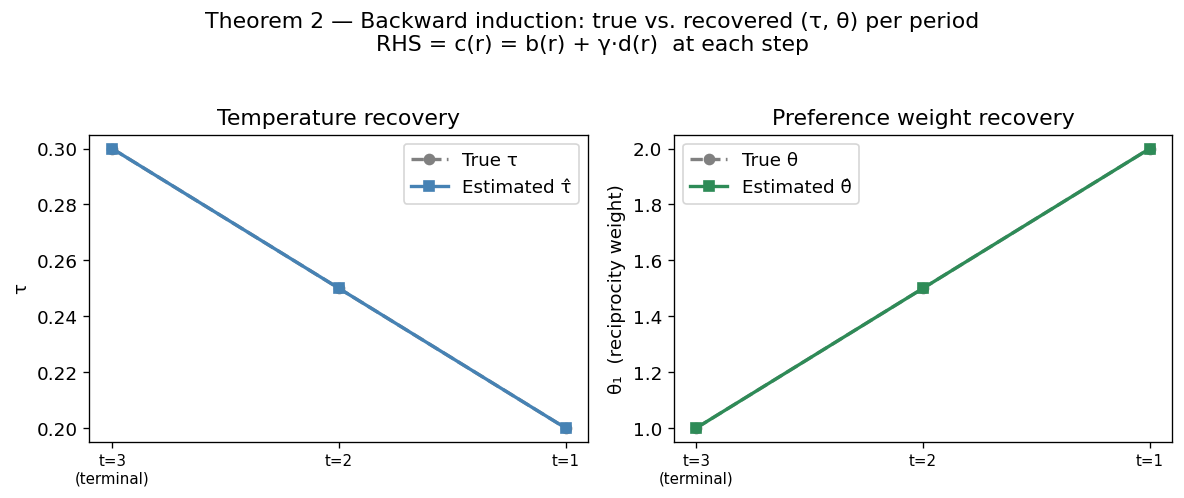

In [15]:
# Toy backward induction: T=3 periods, 1 feature (reciprocity), discrete state & action space

T_game   = 3
gamma_bi = 0.9
rho_bi   = 0.4
A_bi     = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
X_bi     = np.array([0.2, 0.5, 0.8])

tau_true_bi   = {1: 0.20, 2: 0.25, 3: 0.30}
theta_true_bi = {1: 2.0,  2: 1.5,  3: 1.0}

def u_fn(a, x, theta, rho=rho_bi):
    return -(1 - rho) * a + rho * x + theta * (a * x)

def next_state(a, x):
    """Approximate next state and snap to grid."""
    return X_bi[np.argmin(np.abs(X_bi - (rho_bi * a + (1 - rho_bi) * x)))]

def soft_V(x_grid, Q, tau):
    return {x: tau * np.log(sum(np.exp(Q[(x, a)] / tau) for a in A_bi))
            for x in x_grid}

def build_Q_bi(theta, tau, V_next, x_grid):
    Q = {}
    for x in x_grid:
        for a in A_bi:
            Q[(x, a)] = u_fn(a, x, theta) + gamma_bi * V_next.get(next_state(a, x), 0.0)
    return Q

def solve_bfse_bi(theta_true, tau_true, V_next, x_grid):
    """Solve τ·y = c + Δφ·θ  where c = b + γ·d  (the full continuation-adjusted anchor)."""
    rows = [(x, a, ap) for x in x_grid for a in A_bi for ap in A_bi if a != ap]
    Q_t  = build_Q_bi(theta_true, tau_true, V_next, x_grid)

    c_list, dphi_list, y_list = [], [], []
    for x, a, ap in rows:
        # Log-odds from true CCPs
        log_denom = np.log(sum(np.exp(Q_t[(x, a_)] / tau_true) for a_ in A_bi) + 1e-15)
        y = Q_t[(x, a)] / tau_true - log_denom - (Q_t[(x, ap)] / tau_true - log_denom)

        # b(r) = monetary anchor
        b = -(1 - rho_bi) * (a - ap)

        # d(r) = continuation difference: V̄_{t+1}(x,a) − V̄_{t+1}(x,a')
        d = V_next.get(next_state(a, x), 0.0) - V_next.get(next_state(ap, x), 0.0)

        # c(r) = b(r) + γ·d(r)  ← the correct RHS
        c_list.append(b + gamma_bi * d)
        dphi_list.append((a - ap) * x)
        y_list.append(y)

    c_vec    = np.array(c_list)
    dphi_arr = np.array(dphi_list).reshape(-1, 1)
    y_arr    = np.array(y_list)
    design   = np.column_stack([y_arr, -dphi_arr])
    params, *_ = lstsq(design, c_vec)
    return float(params[0]), float(params[1])

# --- Run backward induction ---
V_next_bi = {x: 0.0 for x in X_bi}   # V_{T+1} = 0
tau_hat_bi, theta_hat_bi = {}, {}

for t in range(T_game, 0, -1):
    τh, θh = solve_bfse_bi(theta_true_bi[t], tau_true_bi[t], V_next_bi, X_bi)
    tau_hat_bi[t]   = τh
    theta_hat_bi[t] = θh
    Q_t       = build_Q_bi(theta_true_bi[t], tau_true_bi[t], V_next_bi, X_bi)
    V_next_bi = soft_V(X_bi, Q_t, tau_true_bi[t])

# --- Print recovery ---
print(f"{'Period':<10} {'τ true':<10} {'τ hat':<10} {'θ true':<10} {'θ hat':<10}")
for t in [T_game, T_game-1, T_game-2]:
    print(f"t={t:<8} {tau_true_bi[t]:<10.4f} {tau_hat_bi[t]:<10.4f} "
          f"{theta_true_bi[t]:<10.4f} {theta_hat_bi[t]:<10.4f}")

# --- Plot ---
t_vals  = [T_game, T_game-1, T_game-2]
xlabels = [f"t={T_game}\n(terminal)", f"t={T_game-1}", f"t={T_game-2}"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_vals, [tau_true_bi[t]  for t in t_vals], "o--", color="gray",      lw=2, label="True τ")
axes[0].plot(t_vals, [tau_hat_bi[t]   for t in t_vals], "s-",  color="steelblue", lw=2, label="Estimated τ̂")
axes[0].set_xticks(t_vals); axes[0].set_xticklabels(xlabels, fontsize=9)
axes[0].invert_xaxis()
axes[0].set_ylabel("τ"); axes[0].set_title("Temperature recovery")
axes[0].legend()

axes[1].plot(t_vals, [theta_true_bi[t] for t in t_vals], "o--", color="gray",     lw=2, label="True θ")
axes[1].plot(t_vals, [theta_hat_bi[t]  for t in t_vals], "s-",  color="seagreen", lw=2, label="Estimated θ̂")
axes[1].set_xticks(t_vals); axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].invert_xaxis()
axes[1].set_ylabel("θ₁  (reciprocity weight)"); axes[1].set_title("Preference weight recovery")
axes[1].legend()

fig.suptitle("Theorem 2 — Backward induction: true vs. recovered (τ, θ) per period\n"
             "RHS = c(r) = b(r) + γ·d(r)  at each step", y=1.03)
plt.tight_layout(); plt.show()

---
## 11 · Scope: Unconditional Types and the Mixture Extension

The identification results above presume the **support clause of Assumption 2** holds at the relevant state-action comparisons: $P_t(a \mid x) > 0$ for every action in the action set. In real PGG data this is sometimes violated by **behaviourally degenerate sub-populations**: subjects whose actions are statistically constant regardless of state. The Fischbacher–Gächter–Fehr (2001) typology calls these **unconditional defectors** ($a \equiv 0$) and **unconditional cooperators** ($a \equiv e$).

For such sub-populations the empirical CCP collapses to a point mass, $P_t(a \mid x) = \mathbf{1}\{a = a^\ast\}$, and the log-odds $y_t(r) = \log P_t(a \mid x) - \log P_t(a' \mid x)$ are *undefined* for any $a' \neq a^\ast$. The stacked structural equation has **no usable rows on this slice**, and $(\tau_t, \boldsymbol{\theta}_t)$ are not point-identified there.

### Finite mixture extension

Partition the population into three structural sub-populations with prior shares $(\pi_0, \pi_e, \pi_c) \in \Delta^2$, $\pi_c = 1 - \pi_0 - \pi_e$:

$$\boxed{\;P_t(a \mid x;\, \tau_t,\, \boldsymbol{\theta}_t,\, \pi) \;=\; \pi_0\,\mathbf{1}\{a = 0\} \;+\; \pi_e\,\mathbf{1}\{a = e\} \;+\; \pi_c\,P^{\mathrm{BFSE}}_t(a \mid x;\, \tau_t,\, \boldsymbol{\theta}_t).\;}$$

* The mixture weights $(\pi_0, \pi_e)$ are **non-parametrically identified** from the empirical mass on degenerate trajectories — the share of agents whose entire action sequence collapses to $0$ or $e$. Neither the support nor the non-collinearity conditions are needed.
* Theorems 1 and 2 then apply **to the conditional sub-population of mass $\pi_c$**, on which both conditions hold by construction.

### Corner-solution interpretation ($\tau_t \to 0$)

Unconditional types are also the $\tau_t \to 0$ **corner solutions** of the original BFSE model. The unconditional defector corresponds to any $\boldsymbol{\theta}_t$ for which the monetary anchor $-(1-\rho)(a-0)$ dominates the social return $\boldsymbol{\theta}_t^\top \Delta\boldsymbol{\varphi}_t$ at every $x$; symmetrically for the unconditional cooperator at $a = e$. The data identify only **the half-space of $\boldsymbol{\theta}_t$ consistent with the binding corner**. Point identification of $\boldsymbol{\theta}_t$ within an unconditional type requires either auxiliary structure (a prior) or out-of-sample variation that perturbs the corner.

### What this section is for

Two practical consequences in the empirical work:

1. **Per-cluster MLE fits that hit a bound** (`at_bound = True`) — typically the always-defect and always-cooperate clusters — are flagged not as estimator failures but as **identification scope limits**: those clusters lie outside the conditional sub-population that BFSE addresses.
2. **The headline structural estimates** are reported on the **conditional sub-population**. The mixture shares $(\pi_0, \pi_e)$ are reported separately.

See `bfse_empirical.ipynb` §5 for the empirical identification of $\pi_0, \pi_e, \pi_c$ on this dataset.

---
## 12 · Key Takeaways

| Concept | Formula | Role |
|---------|---------|------|
| Monetary payoff | $m = e - a + \rho\bigl(a + \sum_{j\neq i}c_j\bigr)$ | Baseline utility |
| Structural utility | $u = \mathbb{E}[m + \boldsymbol{\theta}^\top\boldsymbol{\phi}]$ | Maps preferences → actions |
| Soft Q / Value | $V = \tau\log\sum\exp(Q/\tau)$ | Bounded-rationality policy |
| CCP (logit) | $P_t(a\mid x) = \operatorname{softmax}(Q/\tau)$ | Observables for estimation |
| **Belief-free gradient** | $\Delta\mathbb{E}[m] = -(1-\rho)(a-a')$ | **Identification anchor** (Lemma 1) |
| **Continuation-adjusted anchor** | $\mathbf{c}_t = \mathbf{b}_t + \gamma\mathbf{d}_t$ | Known offset at period $t$ (Def 1) |
| **Stacked structural eq.** | $\tau_t\mathbf{y}_t = \mathbf{c}_t + \Delta\boldsymbol{\Phi}_t\boldsymbol{\theta}_t$ | Population linear system |
| **Terminal identification** | $\operatorname{rank}(\Delta\boldsymbol{\Phi}_T)=d$ and $\mathbf{b}_T\notin\operatorname{Col}(\Delta\boldsymbol{\Phi}_T)$ | **Point-identifies $(\tau_T,\boldsymbol{\theta}_T)$** (Thm 1) |
| **Recursive identification** | Backward induction from $T$ using known $\mathbf{c}_t$ | **Identifies all periods** (Thm 2) |

### The Big Picture

1. **Lemma 1** establishes that the marginal monetary cost of contributing is $-(1-\rho)$ — fixed by the institution, belief-free. This is the anchor.
2. **Theorem 1** shows that at the terminal period (no continuation), $(\tau_T, \boldsymbol{\theta}_T)$ is injectively identified by the stacked structural equation, provided social features are not pure affine functions of $a$ (no warm glow).
3. **Theorem 2** extends identification to all earlier periods by backward induction — once future parameters are known, the continuation value $V_{t+1}$ is determined, and each earlier period reduces to the same terminal-period problem.

### Theory vs. practice

The stacked equation $\tau_t \mathbf{y}_t = \mathbf{c}_t + \Delta\boldsymbol{\Phi}_t \boldsymbol{\theta}_t$ identifies $(\tau, \boldsymbol{\theta})$ in **closed form on the population**. In a finite sample we never observe the population log-odds — we observe noisy empirical log-odds $\hat{\mathbf{y}}_t$, and substituting them into OLS attenuates $\hat\tau$ toward zero (classical errors-in-variables). The diagnostic in `diagnose_tau.py` shows the partial-$R^2$ of $\hat y$ on $\hat b$ after residualising $\Delta\hat\Phi$ collapses to $\approx 0.001$.

**The empirical engine is therefore not OLS but direct MLE on the soft-Logit** (`bfse_mle.py`):
$$\hat{(\tau, \boldsymbol{\theta})} \;=\; \arg\max\nolimits_{\tau,\boldsymbol{\theta}} \sum_{i=1}^{n} \log P(a_i \mid x_i;\, \tau, \boldsymbol{\theta}).$$
The identification *conditions* of Theorem 1 still govern when the likelihood has a unique global maximum; the *estimator* is the likelihood, not OLS. Empirical results live in `bfse_empirical.ipynb`.

---
## A · Appendix — Omitted Proofs

This appendix walks through the formal proofs from `knowledge/paper.tex` (Section A). Each proof is presented in the same logical flow as the paper, with an additional code block where a numerical demonstration helps build intuition.

### A.1 Proof of Lemma 1 (Belief-Free Monetary Gradient)

**Claim.** In the linear public goods environment,
$$\Delta\mathbb{E}_{G_t}\!\bigl[m(a, a')\bigr] = -(1-\rho)(a - a').$$

**Proof.** Start from the payoff function:
$$m(a, \mathbf{c}) = e - a + \rho\!\left(a + \sum_{j\neq i} c_j\right).$$

Take the expectation under the subjective belief kernel $G_t(\mathbf{c} \mid x)$:
$$\mathbb{E}_{G_t}[m(a, \mathbf{c}) \mid x] = \sum_{\mathbf{c}} G_t(\mathbf{c} \mid x)\left[e - (1-\rho)a + \rho\sum_{j\neq i} c_j\right].$$

Because $G_t$ is a valid probability mass function, $\sum_\mathbf{c} G_t(\mathbf{c} \mid x) = 1$. Let $\kappa(x) = \mathbb{E}_{G_t}\!\bigl[\sum_{j\neq i} c_j \mid x\bigr]$. Then
$$\mathbb{E}_{G_t}[m(a, \mathbf{c}) \mid x] = e - (1-\rho)a + \rho\,\kappa(x).$$

Now compare two actions $a$ and $a'$:
$$\Delta\mathbb{E}_{G_t}[m(a, a')] = \bigl(e - (1-\rho)a + \rho\kappa(x)\bigr) - \bigl(e - (1-\rho)a' + \rho\kappa(x)\bigr).$$

**By Assumption 1 (Contemporaneous Independence)**, $G_t(\mathbf{c} \mid x)$ is conditionally independent of the focal agent's simultaneous action $a$. Therefore $\kappa(x)$ is mathematically identical across the two evaluations. The constants $e$ and $\rho\kappa(x)$ cancel exactly:
$$\Delta\mathbb{E}_{G_t}[m(a, a')] = -(1-\rho)a - \bigl(-(1-\rho)a'\bigr) = -(1-\rho)(a - a'). \qquad\square$$

The cancellation of $\kappa(x)$ is the entire trick. The state $x$ and the belief kernel $G_t$ shift *levels* of expected payoff arbitrarily — but they leave the *gradient* between any two actions strictly fixed by the institutional parameter $(1 - \rho)$.

In [16]:
# Numerically verify Lemma 1 across many random belief kernels and states
rho_check = 0.4
N_check = 4
A_check = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
n_trials = 1000

rng = np.random.default_rng(0)
mismatches = 0
for _ in range(n_trials):
    # Pick a random pair (a, a') and a random belief distribution over opponent profiles
    a, ap = rng.choice(A_check, size=2, replace=False)
    n_opp = N_check - 1
    # Sample opponent contribution profiles
    samples = rng.uniform(0, 1, size=(2000, n_opp))
    # Empirical expectations
    m_a  = np.mean([e - a  + rho_check * (a  + s.sum()) for s in samples for e in [1.0]])
    m_ap = np.mean([e - ap + rho_check * (ap + s.sum()) for s in samples for e in [1.0]])
    delta_empirical = m_a - m_ap
    delta_theory    = -(1.0 - rho_check) * (a - ap)
    if abs(delta_empirical - delta_theory) > 1e-2:
        mismatches += 1

print(f"Trials  : {n_trials}")
print(f"Mismatches (|empirical - theory| > 0.01): {mismatches}")
print(f"Result  : {'Lemma 1 confirmed empirically' if mismatches == 0 else 'PROBLEM'}")
print()
print("Notice: this holds regardless of the belief distribution sampled.")
print("Only (1 - rho) controls the gradient between actions.")

Trials  : 1000
Mismatches (|empirical - theory| > 0.01): 0
Result  : Lemma 1 confirmed empirically

Notice: this holds regardless of the belief distribution sampled.
Only (1 - rho) controls the gradient between actions.


### A.2 Proof of Theorem 1 (Terminal-Period Exact Identification)

**Claim.** At the terminal round $T$, under Assumptions 2 and 3, the parameter mapping $(\tau_T, \boldsymbol{\theta}_T) \mapsto \mathbf{y}_T$ is injective if and only if
$$\operatorname{rank}(\Delta\boldsymbol{\Phi}_T) = d \quad\text{and}\quad \mathbf{b}_T \notin \operatorname{Col}(\Delta\boldsymbol{\Phi}_T).$$

At $t = T$ the continuation difference vanishes ($\mathbf{d}_T = \mathbf{0}$), so $\mathbf{c}_T = \mathbf{b}_T$ and the stacked equation reduces to
$$\tau_T \mathbf{y}_T = \mathbf{b}_T + \Delta\boldsymbol{\Phi}_T \boldsymbol{\theta}_T. \tag{$*$}$$

---

#### A.2.1 Sufficiency ($\Rightarrow$)

Assume both conditions hold. Suppose two parameter pairs $(\tau, \boldsymbol{\theta})$ and $(\tau', \boldsymbol{\theta}')$ both satisfy $(*)$ for the same observable $\mathbf{y}_T$. Multiplying the first equation by $\tau'$ and the second by $\tau$ and equating right-hand sides:

$$(\tau' - \tau)\,\mathbf{b}_T = \Delta\boldsymbol{\Phi}_T\,\bigl(\tau\boldsymbol{\theta}' - \tau'\boldsymbol{\theta}\bigr). \tag{$\dagger$}$$

*Case 1: $\tau' \ne \tau$.* Divide both sides of $(\dagger)$ by $(\tau' - \tau)$. Then
$$\mathbf{b}_T = \Delta\boldsymbol{\Phi}_T\,\mathbf{v}, \qquad \mathbf{v} := \frac{\tau\boldsymbol{\theta}' - \tau'\boldsymbol{\theta}}{\tau' - \tau} \in \mathbb{R}^d.$$
This puts $\mathbf{b}_T \in \operatorname{Col}(\Delta\boldsymbol{\Phi}_T)$, contradicting the non-spanning assumption. So $\tau' = \tau$.

*Case 2: $\tau' = \tau$.* Substituting back into $(\dagger)$: $\mathbf{0} = \tau \Delta\boldsymbol{\Phi}_T(\boldsymbol{\theta}' - \boldsymbol{\theta})$. Since $\tau > 0$, divide: $\Delta\boldsymbol{\Phi}_T(\boldsymbol{\theta}' - \boldsymbol{\theta}) = \mathbf{0}$. Because $\operatorname{rank}(\Delta\boldsymbol{\Phi}_T) = d$, the matrix has full column rank, its null space is trivial, and $\boldsymbol{\theta}' = \boldsymbol{\theta}$.

Both pairs are identical. The map is injective.

---

#### A.2.2 Necessity of the Rank Condition

Suppose $\operatorname{rank}(\Delta\boldsymbol{\Phi}_T) < d$. By the rank-nullity theorem there exists $\mathbf{h} \in \mathbb{R}^d \setminus \{\mathbf{0}\}$ with $\Delta\boldsymbol{\Phi}_T \mathbf{h} = \mathbf{0}$. For any valid $(\tau, \boldsymbol{\theta})$, the alternative pair $(\tau, \boldsymbol{\theta} + \mathbf{h})$ satisfies
$$\mathbf{b}_T + \Delta\boldsymbol{\Phi}_T(\boldsymbol{\theta} + \mathbf{h}) = \mathbf{b}_T + \Delta\boldsymbol{\Phi}_T\boldsymbol{\theta} = \tau \mathbf{y}_T,$$
producing the same $\mathbf{y}_T$. Two distinct parameter pairs → injectivity fails.

---

#### A.2.3 Necessity of the Non-Spanning Condition

Suppose $\mathbf{b}_T \in \operatorname{Col}(\Delta\boldsymbol{\Phi}_T)$, so $\mathbf{b}_T = \Delta\boldsymbol{\Phi}_T \mathbf{v}$ for some $\mathbf{v} \in \mathbb{R}^d$. Pick any valid $(\tau, \boldsymbol{\theta})$ and any scalar $\lambda > 0$ with $\lambda \ne 1$. Construct the **rescaled pair**:
$$\tau' = \lambda \tau, \qquad \boldsymbol{\theta}' = \lambda \boldsymbol{\theta} + (\lambda - 1)\mathbf{v}.$$

Evaluating the structural mapping for $(\tau', \boldsymbol{\theta}')$ and substituting $\Delta\boldsymbol{\Phi}_T \mathbf{v} = \mathbf{b}_T$:

\begin{align*}
\Gamma(\tau', \boldsymbol{\theta}') &= \frac{1}{\lambda\tau}\mathbf{b}_T + \Delta\boldsymbol{\Phi}_T\left(\frac{\lambda\boldsymbol{\theta} + (\lambda - 1)\mathbf{v}}{\lambda\tau}\right) \\
  &= \frac{1}{\lambda\tau}\mathbf{b}_T + \frac{1}{\tau}\Delta\boldsymbol{\Phi}_T\boldsymbol{\theta} + \frac{\lambda - 1}{\lambda\tau}\mathbf{b}_T \\
  &= \left(\frac{1 + \lambda - 1}{\lambda\tau}\right)\mathbf{b}_T + \frac{1}{\tau}\Delta\boldsymbol{\Phi}_T\boldsymbol{\theta} \\
  &= \frac{1}{\tau}\mathbf{b}_T + \Delta\boldsymbol{\Phi}_T\frac{\boldsymbol{\theta}}{\tau} = \mathbf{y}_T.
\end{align*}

A distinct $(\tau', \boldsymbol{\theta}')$ generates the same $\mathbf{y}_T$. Injectivity fails.

Both conditions are formally **necessary and sufficient**. $\square$

In [17]:
# Numerically demonstrate the lambda-rescaling family of Theorem 1.2.3:
# under warm-glow (phi = a), an entire one-parameter family of (tau', theta') generates
# identical CCPs. Show this explicitly.
from scipy.special import softmax

rho_demo = 0.4
A_demo = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
states_demo = np.array([0.2, 0.5, 0.8])

# "True" parameters
tau_true   = 0.3
theta_true = 1.5

# Warm-glow feature: phi(a) = a  -> Delta phi(r) = (a - a'). v solves b = Delta Phi * v.
# b(r) = -(1-rho)(a - a'),  Delta phi(r) = (a - a').  So v = -(1 - rho).
v_warm_glow = -(1.0 - rho_demo)

def Q_warm(a, x, theta_val, rho=rho_demo):
    # Monetary + warm-glow social: m(a) anchor + theta * a
    return -(1.0 - rho) * a + theta_val * a

def policy(tau_val, theta_val):
    # Population CCP at each state in states_demo
    Pvecs = []
    for x in states_demo:
        Q = np.array([Q_warm(a, x, theta_val) for a in A_demo])
        Pvecs.append(softmax(Q / tau_val))
    return np.array(Pvecs)

P_true = policy(tau_true, theta_true)

print("Lambda rescaling under warm-glow violation — does the policy change?")
print("-" * 70)
print(f"{'lambda':>8s}  {'tau_rescaled':>13s}  {'theta_rescaled':>15s}  {'max |P - P_true|':>18s}")
for lam in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    tau_lam   = lam * tau_true
    theta_lam = lam * theta_true + (lam - 1) * v_warm_glow
    P_lam     = policy(tau_lam, theta_lam)
    diff      = float(np.max(np.abs(P_lam - P_true)))
    print(f"{lam:>8.3f}  {tau_lam:>13.4f}  {theta_lam:>15.4f}  {diff:>18.2e}")

print()
print("All rows produce the SAME CCP. (tau, theta) is unidentified under warm-glow.")

Lambda rescaling under warm-glow violation — does the policy change?
----------------------------------------------------------------------
  lambda   tau_rescaled   theta_rescaled    max |P - P_true|
   0.500         0.1500           1.0500            1.11e-16
   0.750         0.2250           1.2750            1.11e-16
   1.000         0.3000           1.5000            0.00e+00
   1.250         0.3750           1.7250            0.00e+00
   1.500         0.4500           1.9500            1.67e-16
   2.000         0.6000           2.4000            1.11e-16

All rows produce the SAME CCP. (tau, theta) is unidentified under warm-glow.


### A.3 Proof of Theorem 2 (Recursive Exact Identification)

**Claim.** Suppose downstream parameters $(\tau_{t+1:T}, \boldsymbol{\theta}_{t+1:T})$ are uniquely identified. Under Assumption 2, period-$t$ parameters are injectively identified if and only if
$$\operatorname{rank}(\Delta\boldsymbol{\Phi}_t) = d \quad\text{and}\quad \mathbf{c}_t \notin \operatorname{Col}(\Delta\boldsymbol{\Phi}_t).$$

**Proof.** Proceed by backward induction. Assume that for every $k = t+1, \dots, T$ the structural parameters $(\tau_k, \boldsymbol{\theta}_k)$ are uniquely identified.

The Soft Value function at $t+1$ is
$$V_{t+1}(x') = \tau_{t+1} \log \sum_{a' \in \mathcal{A}} \exp\!\left(\frac{Q_{t+1}(x', a';\, \boldsymbol{\theta}_{t+1}, \tau_{t+1})}{\tau_{t+1}}\right).$$

Because the downstream parameters are all known, $V_{t+1}$ is a fully identified, deterministic mapping from $\mathcal{X}_{t+1}$ to $\mathbb{R}$.

At time $t$, the expected continuation value conditional on state $x$ and action $a$ integrates $V_{t+1}$ over contemporaneous opponent actions:
$$\bar{V}_{t+1}(x, a) = \sum_{\mathbf{c} \in \mathcal{A}^{N-1}} G_t(\mathbf{c} \mid x)\,V_{t+1}\bigl(f(x, a, \mathbf{c})\bigr).$$

Under Assumption 2, $G_t$ is strictly known. The mechanical state transition $f$ is deterministic. $V_{t+1}$ is known. So the integration evaluates to a **known deterministic scalar** for every $(x, a)$. Consequently, for any row $r = (x, a, a')$:
$$d_t(r) = \bar{V}_{t+1}(x, a) - \bar{V}_{t+1}(x, a')$$
is a completely known scalar, and the stacked continuation difference vector $\mathbf{d}_t \in \mathbb{R}^{M_t}$ is a completely determined population vector.

Define the continuation-adjusted anchor (Definition 1): $\mathbf{c}_t = \mathbf{b}_t + \gamma \mathbf{d}_t$. Because $\mathbf{b}_t$, $\gamma$, and $\mathbf{d}_t$ are known deterministic objects, $\mathbf{c}_t$ is a known deterministic vector.

The parameter-to-policy map at time $t$ reduces to the stacked structural equation
$$\tau_t \mathbf{y}_t = \mathbf{c}_t + \Delta\boldsymbol{\Phi}_t \boldsymbol{\theta}_t.$$

Because $\mathbf{c}_t$ serves the exact structural role as an exogenous, deterministic vector intercept, this equation is **algebraically isomorphic to the terminal-period equation** of Theorem 1 (substitute $\mathbf{c}_t$ in place of $\mathbf{b}_T$). The exact algebraic mechanics of A.2 directly apply: $(\tau_t, \boldsymbol{\theta}_t)$ is injectively identified iff
$$\operatorname{rank}(\Delta\boldsymbol{\Phi}_t) = d \quad\text{and}\quad \mathbf{c}_t \notin \operatorname{Col}(\Delta\boldsymbol{\Phi}_t).$$

By induction, exact point identification is established dynamically from $T$ down to $1$. $\square$

---

The induction chain is:
$$\underbrace{(\hat\tau_T, \hat{\boldsymbol{\theta}}_T)}_{\text{Thm 1}}
\;\longrightarrow\; \hat{V}_T
\;\longrightarrow\; \mathbf{d}_{T-1}
\;\longrightarrow\; \mathbf{c}_{T-1}
\;\longrightarrow\; \underbrace{(\hat\tau_{T-1}, \hat{\boldsymbol{\theta}}_{T-1})}_{\text{Thm 2}}
\;\longrightarrow\; \cdots
\;\longrightarrow\; (\hat\tau_1, \hat{\boldsymbol{\theta}}_1).$$

This is what `bfse_mle_dynamic.py` implements numerically with MLE in place of OLS (Stage D-MLE in `bfse_empirical.ipynb` Section 5).